# Classical baselines for EHRSHOT-MEDS: `guo_readmission` and `guo_icu`

Цель ноутбука: построить корректный leakage-safe датасет для двух выбранных задач EHRSHOT-MEDS и сравнить классические модели:

- `DummyClassifier` как sanity-check baseline;
- `LogisticRegression` как простой интерпретируемый baseline;
- `RandomForestClassifier` как классический нелинейный tree-based baseline;
- `HistGradientBoostingClassifier` как sklearn boosting baseline;
- `CatBoostClassifier`.

Ключевой принцип: для каждой label row признаки считаются только из событий пациента до `prediction_time`.

```text
event.time <= prediction_time
```

Иначе модель увидит будущую информацию, и метрики будут завышены.

## 0. Setup

Ожидаемая структура:

```text
EHRSHOT_MEDS/
  data/data.parquet
  metadata/codes.parquet
  metadata/subject_splits.parquet
  labels/guo_readmission/labels.parquet
  labels/guo_icu/labels.parquet
```

In [2]:
from pathlib import Path
import re
import warnings

import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt

from sklearn.dummy import DummyClassifier
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    brier_score_loss,
    log_loss,
    f1_score,
    precision_score,
    recall_score,
    balanced_accuracy_score,
    confusion_matrix,
    precision_recall_curve,
    roc_curve,
)
from sklearn.utils.class_weight import compute_sample_weight

warnings.filterwarnings("ignore")

RANDOM_STATE = 42

EHRSHOT_ROOT = Path("EHRSHOT_MEDS")

DATA_PATH = EHRSHOT_ROOT / "data" / "data.parquet"
SPLITS_PATH = EHRSHOT_ROOT / "metadata" / "subject_splits.parquet"
LABELS_DIR = EHRSHOT_ROOT / "labels"

assert DATA_PATH.exists(), f"Не найден data.parquet: {DATA_PATH}"
assert SPLITS_PATH.exists(), f"Не найден subject_splits.parquet: {SPLITS_PATH}"
assert LABELS_DIR.exists(), f"Не найдена папка labels: {LABELS_DIR}"

CACHE_DIR = Path("ehrshot_baseline_cache")
CACHE_DIR.mkdir(exist_ok=True)

print("EHRSHOT_ROOT:", EHRSHOT_ROOT)
print("DATA_PATH:", DATA_PATH)
print("SPLITS_PATH:", SPLITS_PATH)
print("LABELS_DIR:", LABELS_DIR)
print("CACHE_DIR:", CACHE_DIR)

EHRSHOT_ROOT: EHRSHOT_MEDS
DATA_PATH: EHRSHOT_MEDS/data/data.parquet
SPLITS_PATH: EHRSHOT_MEDS/metadata/subject_splits.parquet
LABELS_DIR: EHRSHOT_MEDS/labels
CACHE_DIR: ehrshot_baseline_cache


## 1. Load events, splits and task labels

В EHRSHOT-MEDS события лежат в одной event table. Labels лежат отдельно по задачам.

Для baseline берем две задачи:

- `guo_readmission`;
- `guo_icu`.

Обе задачи бинарные, target лежит в `boolean_value`.

In [3]:
events_lf = pl.scan_parquet(str(DATA_PATH))
splits = pl.read_parquet(SPLITS_PATH)

task_to_label_file = {
    p.parent.name: p
    for p in sorted(LABELS_DIR.glob("*/labels.parquet"))
}

SELECTED_TASKS = {
    "guo_readmission": {
        "task_description": "30-day readmission after discharge",
        "index_time": "23:59 в день выписки пациента",
        "target": "Повторная госпитализация после выписки",
        "horizon": "30 дней после выписки",
    },
    "guo_icu": {
        "task_description": "ICU transfer during current admission",
        "index_time": "23:59 в день госпитализации / admission",
        "target": "Перевод пациента в ICU",
        "horizon": "Текущая госпитализация / admission episode",
    },
}

for task_name in SELECTED_TASKS:
    assert task_name in task_to_label_file, f"Не найден label file для {task_name}"

print("Events schema:")
print(events_lf.collect_schema())

print("\nSplits:")
display(splits.group_by("split").agg(pl.len().alias("n_subjects")).to_pandas())

print("\nSelected label files:")
for task_name in SELECTED_TASKS:
    print(task_name, "->", task_to_label_file[task_name])

Events schema:
Schema({'subject_id': Int64, 'time': Datetime(time_unit='us', time_zone=None), 'code': String, 'numeric_value': Float32, 'text_value': String, 'unit': String, 'omop_table': String})

Splits:


,split,n_subjects
0,train,2295
1,tuning,2232
2,held_out,2212



Selected label files:
guo_readmission -> EHRSHOT_MEDS/labels/guo_readmission/labels.parquet
guo_icu -> EHRSHOT_MEDS/labels/guo_icu/labels.parquet


In [4]:
def detect_label_col(lf: pl.LazyFrame) -> str:
    candidate_cols = [
        "boolean_value",
        "integer_value",
        "float_value",
        "categorical_value",
        "label",
        "value",
    ]
    schema_cols = lf.collect_schema().names()
    existing = [c for c in candidate_cols if c in schema_cols]

    if not existing:
        raise ValueError(f"No known label column found. Schema: {schema_cols}")

    non_null_counts = (
        lf.select([pl.col(c).is_not_null().sum().alias(c) for c in existing])
        .collect()
        .to_pandas()
        .iloc[0]
    )

    non_null_cols = non_null_counts[non_null_counts > 0]
    if len(non_null_cols) == 0:
        raise ValueError(f"All candidate label columns are null. Existing: {existing}")

    return non_null_cols.index[0]


def load_task_labels(task_name: str) -> pl.DataFrame:
    label_path = task_to_label_file[task_name]
    lf = pl.scan_parquet(str(label_path))
    label_col = detect_label_col(lf)

    labels = (
        pl.read_parquet(label_path)
        .with_row_index("row_id")
        .with_columns([
            pl.col(label_col).cast(pl.Int8).alias("label"),
            pl.lit(task_name).alias("task"),
        ])
        .join(splits, on="subject_id", how="left")
        .select([
            "task",
            "row_id",
            "subject_id",
            "prediction_time",
            "label",
            "split",
        ])
    )

    return labels


labels_by_task = {
    task_name: load_task_labels(task_name)
    for task_name in SELECTED_TASKS
}

for task_name, labels in labels_by_task.items():
    print("\n" + "=" * 100)
    print(task_name)
    display(labels.head().to_pandas())

    summary = (
        labels
        .group_by("label")
        .agg([
            pl.len().alias("n_examples"),
            pl.col("subject_id").n_unique().alias("n_patients"),
        ])
        .sort("label")
        .to_pandas()
    )
    display(summary)

    n_examples = labels.height
    n_patients = labels["subject_id"].n_unique()
    n_positive = int(labels["label"].sum())
    event_rate = n_positive / n_examples

    print(f"n_examples = {n_examples:,}")
    print(f"n_patients = {n_patients:,}")
    print(f"n_positive = {n_positive:,}")
    print(f"event_rate = {event_rate:.4f} ({event_rate * 100:.2f}%)")


guo_readmission


,task,row_id,subject_id,prediction_time,label,split
0,guo_readmission,0,115972658,2009-08-29 23:59:00,0,tuning
1,guo_readmission,1,121124987,2014-06-18 23:59:00,0,train
2,guo_readmission,2,115972175,2010-02-06 23:59:00,0,train
3,guo_readmission,3,115972225,2010-05-18 23:59:00,0,held_out
4,guo_readmission,4,115973258,2022-07-23 23:59:00,0,train


,label,n_examples,n_patients
0,0,6092,3709
1,1,911,474


n_examples = 7,003
n_patients = 3,718
n_positive = 911
event_rate = 0.1301 (13.01%)

guo_icu


,task,row_id,subject_id,prediction_time,label,split
0,guo_icu,0,115973157,2022-12-09 23:59:00,0,tuning
1,guo_icu,1,115973052,2017-01-08 23:59:00,0,tuning
2,guo_icu,2,115973052,2017-02-11 23:59:00,1,tuning
3,guo_icu,3,115973052,2017-04-09 23:59:00,0,tuning
4,guo_icu,4,115973052,2017-04-21 23:59:00,0,tuning


,label,n_examples,n_patients
0,0,6201,3515
1,1,290,266


n_examples = 6,491
n_patients = 3,617
n_positive = 290
event_rate = 0.0447 (4.47%)


## 2. What we predict

Эта таблица фиксирует постановку задач.

Важно:

- `prediction_time` — технический cutoff в данных;
- `index time` — клиническая интерпретация этого cutoff;
- признаки строим только по событиям `event.time <= prediction_time`;
- target берется из label-файла.

In [5]:
task_problem_rows = []

for task_name, labels in labels_by_task.items():
    meta = SELECTED_TASKS[task_name]
    n_examples = labels.height
    n_patients = labels["subject_id"].n_unique()
    n_positive = int(labels["label"].sum())
    n_negative = n_examples - n_positive

    task_problem_rows.append({
        "task": task_name,
        "index_time": meta["index_time"],
        "technical_cutoff": "prediction_time",
        "available_history": "Все события пациента с event.time <= prediction_time",
        "target": meta["target"],
        "horizon": meta["horizon"],
        "n_examples": n_examples,
        "n_patients": n_patients,
        "n_positive": n_positive,
        "n_negative": n_negative,
        "event_rate": n_positive / n_examples,
        "event_rate_percent": round(100 * n_positive / n_examples, 2),
    })

task_problem_df = pd.DataFrame(task_problem_rows)
display(task_problem_df)

,task,index_time,technical_cutoff,available_history,target,horizon,n_examples,n_patients,n_positive,n_negative,event_rate,event_rate_percent
0,guo_readmission,23:59 в день выписки пациента,prediction_time,Все события пациента с event.time <= predictio...,Повторная госпитализация после выписки,30 дней после выписки,7003,3718,911,6092,0.130087,13.01
1,guo_icu,23:59 в день госпитализации / admission,prediction_time,Все события пациента с event.time <= predictio...,Перевод пациента в ICU,Текущая госпитализация / admission episode,6491,3617,290,6201,0.044677,4.47


## 3. Feature engineering strategy

Собираем простой, но нормальный leakage-safe tabular dataset.

Признаки:

1. **Global history features**
   - число событий до `prediction_time`;
   - число уникальных кодов;
   - число numeric events;
   - число text events;
   - длина доступной истории в днях;
   - сколько дней прошло с последнего события.

2. **Code family counts**
   - `LOINC`, `SNOMED`, `RxNorm`, `CPT4`, `Visit` и другие крупные семейства.

3. **Recent-window features**
   - агрегаты за последние 30, 90 и 365 дней до `prediction_time`.

4. **Top code count features**
   - частоты top-N кодов, выбранных только по train split.

5. **Top numeric code features**
   - для top numeric кодов считаем last/mean/count до `prediction_time`.

Примечание: feature construction может занять несколько минут, потому что для каждой label row нужно собрать историю пациента до `prediction_time`.

In [6]:
TOP_N_CODES = 500
TOP_N_NUMERIC_CODES = 40
LOOKBACK_DAYS = [30, 90, 365]

MAIN_CODE_FAMILIES = [
    "LOINC",
    "SNOMED",
    "RxNorm",
    "CPT4",
    "Visit",
    "Domain",
    "CARE_SITE",
    "Medicare Specialty",
    "RxNorm Extension",
    "CMS Place of Service",
    "ICD10PCS",
    "ICD9Proc",
    "Cancer Modifier",
    "Gender",
    "Ethnicity",
    "Race",
    "CVX",
    "HCPCS",
    "OMOP Extension",
    "ICDO3",
    "Condition Type"
]


def safe_feature_name(x: str) -> str:
    x = str(x)
    x = x.replace("/", "__")
    x = x.replace(" ", "_")
    x = re.sub(r"[^A-Za-z0-9_]+", "_", x)
    return x


def pivot_long_to_wide(
    df_long: pd.DataFrame,
    index_col: str,
    columns_col: str,
    values_col: str,
    prefix: str,
) -> pd.DataFrame:
    if df_long.empty:
        return pd.DataFrame(columns=[index_col]).set_index(index_col)

    wide = (
        df_long
        .pivot_table(
            index=index_col,
            columns=columns_col,
            values=values_col,
            aggfunc="sum",
            fill_value=0,
        )
    )

    wide.columns = [f"{prefix}{safe_feature_name(c)}" for c in wide.columns]
    wide = wide.astype(np.float32)
    return wide


def make_history_lf(
    labels: pl.DataFrame,
    include_prediction_time: bool = True,
) -> pl.LazyFrame:
    """
    Возвращает legal history для каждой label row.

    include_prediction_time=True:
        используем события event.time <= prediction_time.

    include_prediction_time=False:
        используем более строгий вариант event.time < prediction_time.
        Этот режим нужен для sensitivity check, особенно для guo_icu.
    """
    labels_key_lf = labels.lazy().select([
        "row_id",
        "subject_id",
        "prediction_time",
    ])

    if include_prediction_time:
        time_filter = pl.col("time") <= pl.col("prediction_time")
    else:
        time_filter = pl.col("time") < pl.col("prediction_time")

    history_lf = (
        labels_key_lf
        .join(events_lf, on="subject_id", how="inner")
        .filter(time_filter)
        .with_columns([
            (pl.col("prediction_time") - pl.col("time"))
            .dt.total_days()
            .alias("days_before_prediction"),

            pl.col("code")
            .str.split("/")
            .list.get(0)
            .fill_null("UNKNOWN")
            .alias("code_family"),
        ])
    )

    return history_lf

In [7]:
def select_top_codes_from_train(
    history_lf: pl.LazyFrame,
    labels: pl.DataFrame,
    top_n_codes: int,
    top_n_numeric_codes: int,
):
    train_row_ids = labels.filter(pl.col("split") == "train").select("row_id")

    train_history_lf = history_lf.join(
        train_row_ids.lazy(),
        on="row_id",
        how="inner",
    )

    top_codes = (
        train_history_lf
        .group_by("code")
        .agg(pl.len().alias("n"))
        .sort("n", descending=True)
        .head(top_n_codes)
        .collect()
        .get_column("code")
        .to_list()
    )

    top_numeric_codes = (
        train_history_lf
        .filter(pl.col("numeric_value").is_not_null())
        .group_by("code")
        .agg(pl.len().alias("n"))
        .sort("n", descending=True)
        .head(top_n_numeric_codes)
        .collect()
        .get_column("code")
        .to_list()
    )

    return top_codes, top_numeric_codes

In [8]:
def build_features_for_task(
    task_name: str,
    labels: pl.DataFrame,
    top_n_codes: int = TOP_N_CODES,
    top_n_numeric_codes: int = TOP_N_NUMERIC_CODES,
    lookback_days: list[int] = LOOKBACK_DAYS,
    use_cache: bool = True,
    include_prediction_time: bool = True,
) -> pd.DataFrame:
    """
    Строит leakage-safe tabular features для одной EHRSHOT задачи.

    На выходе:
    - одна строка = одна label row;
    - есть metadata columns: task, row_id, subject_id, prediction_time, label, split;
    - остальные колонки = признаки.
    """
    if include_prediction_time:
        # Оставляем старое имя cache-файла для совместимости с уже посчитанными признаками.
        cache_path = CACHE_DIR / f"{task_name}_features_top{top_n_codes}_num{top_n_numeric_codes}.parquet"
    else:
        cache_path = CACHE_DIR / f"{task_name}_lt_prediction_time_features_top{top_n_codes}_num{top_n_numeric_codes}.parquet"

    if use_cache and cache_path.exists():
        print(f"[{task_name}] Loading cached features:", cache_path)
        return pd.read_parquet(cache_path)

    print(f"[{task_name}] Building history lazy frame...")
    history_lf = make_history_lf(
        labels=labels,
        include_prediction_time=include_prediction_time,
    )

    print(f"[{task_name}] Selecting top codes from train only...")
    top_codes, top_numeric_codes = select_top_codes_from_train(
        history_lf=history_lf,
        labels=labels,
        top_n_codes=top_n_codes,
        top_n_numeric_codes=top_n_numeric_codes,
    )

    print(f"[{task_name}] n_top_codes:", len(top_codes))
    print(f"[{task_name}] n_top_numeric_codes:", len(top_numeric_codes))

    # 1. Basic global history features
    print(f"[{task_name}] Building basic history features...")
    basic = (
        history_lf
        .group_by("row_id")
        .agg([
            pl.len().alias("n_events_before"),
            pl.col("code").n_unique().alias("n_unique_codes_before"),
            pl.col("code_family").n_unique().alias("n_unique_code_families_before"),
            pl.col("numeric_value").is_not_null().sum().alias("n_numeric_events_before"),
            pl.col("text_value").is_not_null().sum().alias("n_text_events_before"),
            pl.col("time").min().alias("first_event_time_before"),
            pl.col("time").max().alias("last_event_time_before"),
        ])
        .with_columns([
            (
                pl.col("last_event_time_before") - pl.col("first_event_time_before")
            ).dt.total_days().alias("history_span_days_before")
        ])
        .collect()
        .to_pandas()
        .set_index("row_id")
    )

    # 2. Days since last event
    labels_pd = labels.to_pandas().set_index("row_id")
    basic["days_since_last_event"] = (
        pd.to_datetime(labels_pd.loc[basic.index, "prediction_time"])
        - pd.to_datetime(basic["last_event_time_before"])
    ).dt.total_seconds() / 86400

    basic = basic.drop(columns=["first_event_time_before", "last_event_time_before"])
    basic = basic.astype(np.float32)

    # 3. Code family counts
    print(f"[{task_name}] Building code family count features...")
    family_long = (
        history_lf
        .filter(pl.col("code_family").is_in(MAIN_CODE_FAMILIES))
        .group_by(["row_id", "code_family"])
        .agg(pl.len().alias("n"))
        .collect()
        .to_pandas()
    )

    family_wide = pivot_long_to_wide(
        df_long=family_long,
        index_col="row_id",
        columns_col="code_family",
        values_col="n",
        prefix="family_count__",
    )

    # 4. Recent-window basic features
    print(f"[{task_name}] Building recent-window features...")
    window_parts = []
    for days in lookback_days:
        w = (
            history_lf
            .filter(pl.col("days_before_prediction") <= days)
            .group_by("row_id")
            .agg([
                pl.len().alias(f"n_events_last_{days}d"),
                pl.col("code").n_unique().alias(f"n_unique_codes_last_{days}d"),
                pl.col("numeric_value").is_not_null().sum().alias(f"n_numeric_events_last_{days}d"),
                pl.col("code").str.starts_with("Visit/").sum().alias(f"n_visit_events_last_{days}d"),
                pl.col("code").str.starts_with("LOINC/").sum().alias(f"n_loinc_events_last_{days}d"),
                pl.col("code").str.starts_with("SNOMED/").sum().alias(f"n_snomed_events_last_{days}d"),
                pl.col("code").str.starts_with("RxNorm/").sum().alias(f"n_rxnorm_events_last_{days}d"),
                pl.col("code").str.starts_with("CPT4/").sum().alias(f"n_cpt4_events_last_{days}d"),
            ])
            .collect()
            .to_pandas()
            .set_index("row_id")
            .astype(np.float32)
        )
        window_parts.append(w)

    # 5. Top code count features
    print(f"[{task_name}] Building top-code count features...")
    top_code_long = (
        history_lf
        .filter(pl.col("code").is_in(top_codes))
        .group_by(["row_id", "code"])
        .agg(pl.len().alias("n"))
        .collect()
        .to_pandas()
    )

    top_code_wide = pivot_long_to_wide(
        df_long=top_code_long,
        index_col="row_id",
        columns_col="code",
        values_col="n",
        prefix="code_count__",
    )

    # 6. Top numeric code aggregate features
    print(f"[{task_name}] Building top numeric code aggregate features...")
    numeric_long = (
        history_lf
        .filter(
            pl.col("code").is_in(top_numeric_codes)
            & pl.col("numeric_value").is_not_null()
        )
        .sort(["row_id", "code", "time"])
        .group_by(["row_id", "code"])
        .agg([
            pl.col("numeric_value").last().alias("last_value"),
            pl.col("numeric_value").mean().alias("mean_value"),
            pl.col("numeric_value").min().alias("min_value"),
            pl.col("numeric_value").max().alias("max_value"),
            pl.len().alias("n_measurements"),
        ])
        .collect()
        .to_pandas()
    )

    numeric_parts = []
    for value_col, prefix in [
        ("last_value", "num_last__"),
        ("mean_value", "num_mean__"),
        ("min_value", "num_min__"),
        ("max_value", "num_max__"),
        ("n_measurements", "num_count__"),
    ]:
        numeric_parts.append(
            pivot_long_to_wide(
                df_long=numeric_long[["row_id", "code", value_col]],
                index_col="row_id",
                columns_col="code",
                values_col=value_col,
                prefix=prefix,
            )
        )

    # 7. Combine metadata + features
    print(f"[{task_name}] Combining feature matrix...")
    meta = labels.to_pandas().set_index("row_id")

    feature_parts = [basic, family_wide, top_code_wide] + window_parts + numeric_parts

    X = meta.join(feature_parts, how="left")

    # Fill missing feature values with 0.
    # Для count-признаков это значит "не было таких событий".
    # Для numeric last/mean/min/max это допущение baseline; num_count показывает, было ли измерение.
    feature_cols = [
        c for c in X.columns
        if c not in ["task", "subject_id", "prediction_time", "label", "split"]
    ]
    X[feature_cols] = X[feature_cols].fillna(0).astype(np.float32)

    X = X.reset_index()

    if use_cache:
        X.to_parquet(cache_path, index=False)
        print(f"[{task_name}] Saved features to:", cache_path)

    print(f"[{task_name}] Done. Shape:", X.shape)
    return X

## 4. Build datasets for selected tasks

Этот блок может выполняться дольше остальных.  
Если признаки уже были построены, они загрузятся из `ehrshot_baseline_cache`.

In [9]:
datasets = {}

for task_name, labels in labels_by_task.items():
    datasets[task_name] = build_features_for_task(
        task_name=task_name,
        labels=labels,
        top_n_codes=TOP_N_CODES,
        top_n_numeric_codes=TOP_N_NUMERIC_CODES,
        lookback_days=LOOKBACK_DAYS,
        use_cache=True,
    )

for task_name, df in datasets.items():
    print("\n" + "=" * 100)
    print(task_name)
    print(df.shape)
    display(df.head())

[guo_readmission] Loading cached features: ehrshot_baseline_cache/guo_readmission_features_top500_num40.parquet
[guo_icu] Loading cached features: ehrshot_baseline_cache/guo_icu_features_top500_num40.parquet

guo_readmission
(7003, 758)


,row_id,task,subject_id,prediction_time,label,split,n_events_before,n_unique_codes_before,n_unique_code_families_before,n_numeric_events_before,...,num_count__LOINC__8462_4,num_count__LOINC__8478_0,num_count__LOINC__8480_6,num_count__LOINC__8634_8,num_count__LOINC__8636_3,num_count__LOINC__8867_4,num_count__LOINC__9279_1,num_count__LOINC__IO_OUT,num_count__LOINC__LP21258_6,num_count__SNOMED__166900001
0,0,guo_readmission,115972658,2009-08-29 23:59:00,0,tuning,303.0,104.0,10.0,196.0,...,16.0,15.0,17.0,0.0,0.0,28.0,9.0,8.0,12.0,0.0
1,1,guo_readmission,121124987,2014-06-18 23:59:00,0,train,2952.0,332.0,11.0,2440.0,...,125.0,36.0,132.0,1.0,1.0,239.0,70.0,25.0,78.0,0.0
2,2,guo_readmission,115972175,2010-02-06 23:59:00,0,train,1342.0,340.0,12.0,805.0,...,50.0,41.0,51.0,20.0,20.0,109.0,39.0,18.0,71.0,1.0
3,3,guo_readmission,115972225,2010-05-18 23:59:00,0,held_out,835.0,232.0,11.0,446.0,...,28.0,15.0,27.0,0.0,0.0,41.0,21.0,11.0,26.0,0.0
4,4,guo_readmission,115973258,2022-07-23 23:59:00,0,train,6368.0,489.0,14.0,5023.0,...,381.0,372.0,424.0,2.0,2.0,374.0,143.0,86.0,104.0,0.0



guo_icu
(6491, 758)


,row_id,task,subject_id,prediction_time,label,split,n_events_before,n_unique_codes_before,n_unique_code_families_before,n_numeric_events_before,...,num_count__LOINC__8327_9,num_count__LOINC__8462_4,num_count__LOINC__8478_0,num_count__LOINC__8480_6,num_count__LOINC__8634_8,num_count__LOINC__8636_3,num_count__LOINC__8867_4,num_count__LOINC__9279_1,num_count__LOINC__IO_OUT,num_count__LOINC__LP21258_6
0,0,guo_icu,115973157,2022-12-09 23:59:00,0,tuning,5181.0,493.0,16.0,3377.0,...,23.0,281.0,245.0,305.0,3.0,3.0,280.0,128.0,2.0,133.0
1,1,guo_icu,115973052,2017-01-08 23:59:00,0,tuning,811.0,212.0,12.0,442.0,...,5.0,59.0,59.0,65.0,1.0,1.0,74.0,6.0,2.0,47.0
2,2,guo_icu,115973052,2017-02-11 23:59:00,1,tuning,2260.0,294.0,14.0,1704.0,...,7.0,222.0,224.0,229.0,5.0,7.0,229.0,18.0,4.0,138.0
3,3,guo_icu,115973052,2017-04-09 23:59:00,0,tuning,16137.0,733.0,14.0,12954.0,...,48.0,883.0,928.0,1049.0,237.0,328.0,1145.0,360.0,165.0,490.0
4,4,guo_icu,115973052,2017-04-21 23:59:00,0,tuning,17682.0,803.0,14.0,13859.0,...,58.0,933.0,977.0,1100.0,239.0,330.0,1196.0,392.0,178.0,528.0


## 5. Dataset sanity checks

Проверяем:

- размер датасета;
- split distribution;
- positive rate по split;
- нет ли пропусков в target/split;
- сколько признаков получилось.

In [10]:
def dataset_sanity_check(df: pd.DataFrame, task_name: str):
    feature_cols = [
        c for c in df.columns
        if c not in ["task", "row_id", "subject_id", "prediction_time", "label", "split"]
    ]

    print("\n" + "=" * 100)
    print(task_name)
    print("shape:", df.shape)
    print("n_features:", len(feature_cols))
    print("label nulls:", df["label"].isna().sum())
    print("split nulls:", df["split"].isna().sum())

    split_summary = (
        df.groupby("split")
        .agg(
            n_examples=("label", "size"),
            n_patients=("subject_id", "nunique"),
            n_positive=("label", "sum"),
            event_rate=("label", "mean"),
        )
        .reset_index()
    )
    split_summary["event_rate_percent"] = split_summary["event_rate"] * 100
    display(split_summary)

    return split_summary, feature_cols


feature_cols_by_task = {}

for task_name, df in datasets.items():
    _, feature_cols = dataset_sanity_check(df, task_name)
    feature_cols_by_task[task_name] = feature_cols


guo_readmission
shape: (7003, 758)
n_features: 752
label nulls: 0
split nulls: 0


,split,n_examples,n_patients,n_positive,event_rate,event_rate_percent
0,held_out,2189,1190,260,0.118776,11.877570
1,train,2608,1337,370,0.141871,14.187117
2,tuning,2206,1191,281,0.127380,12.737987



guo_icu
shape: (6491, 758)
n_features: 752
label nulls: 0
split nulls: 0


,split,n_examples,n_patients,n_positive,event_rate,event_rate_percent
0,held_out,2037,1154,85,0.041728,4.172803
1,train,2402,1306,113,0.047044,4.704413
2,tuning,2052,1157,92,0.044834,4.483431


## 6. Modeling utilities

Метрики:

- **AUROC** — общее качество ранжирования positive выше negative;
- **AUPRC / Average Precision** — более важна при class imbalance;
- **Brier score** — качество вероятностной калибровки, меньше лучше;
- **LogLoss** — качество вероятностей, меньше лучше;
- **F1 / Precision / Recall** — считаются по threshold;
- **Balanced Accuracy** — полезна при дисбалансе.

Threshold выбираем на `tuning` split, затем применяем на `held_out`.

In [11]:
def make_model_zoo(y_train: np.ndarray):
    models = {}

    models["Dummy_prior"] = DummyClassifier(
        strategy="prior",
        random_state=RANDOM_STATE,
    )

    models["LogisticRegression_balanced"] = Pipeline([
        ("imputer", SimpleImputer(strategy="constant", fill_value=0)),
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            max_iter=3000,
            class_weight="balanced",
            solver="lbfgs",
            random_state=RANDOM_STATE,
        )),
    ])

    models["RandomForest_balanced"] = RandomForestClassifier(
        n_estimators=400,
        max_depth=12,
        min_samples_leaf=10,
        class_weight="balanced_subsample",
        n_jobs=-1,
        random_state=RANDOM_STATE,
    )

    models["HistGradientBoosting"] = HistGradientBoostingClassifier(
        learning_rate=0.05,
        max_iter=200,
        max_leaf_nodes=31,
        l2_regularization=0.1,
        random_state=RANDOM_STATE,
    )

    try:
        from catboost import CatBoostClassifier

        models["CatBoost_balanced"] = CatBoostClassifier(
            iterations=500,
            depth=6,
            learning_rate=0.05,
            loss_function="Logloss",
            eval_metric="AUC",
            auto_class_weights="Balanced",
            random_seed=RANDOM_STATE,
            verbose=False,
            allow_writing_files=False,
        )
    except Exception as e:
        print("CatBoost is not available, skipping. Reason:", repr(e))

    return models


def get_positive_proba(model, X):
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X)[:, 1]
    raise ValueError(f"Model {model} does not support predict_proba")


def choose_threshold(y_true, y_prob, metric: str = "f1"):
    thresholds = np.linspace(0.01, 0.99, 99)

    best_threshold = 0.5
    best_score = -np.inf

    for thr in thresholds:
        y_pred = (y_prob >= thr).astype(int)

        if metric == "f1":
            score = f1_score(y_true, y_pred, zero_division=0)
        elif metric == "balanced_accuracy":
            score = balanced_accuracy_score(y_true, y_pred)
        elif metric == "youden":
            tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
            sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
            specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
            score = sensitivity + specificity - 1
        else:
            raise ValueError(f"Unknown threshold metric: {metric}")

        if score > best_score:
            best_score = score
            best_threshold = thr

    return best_threshold, best_score


def safe_auc(y_true, y_prob):
    if len(np.unique(y_true)) < 2:
        return np.nan
    return roc_auc_score(y_true, y_prob)


def safe_log_loss(y_true, y_prob):
    eps = 1e-7
    y_prob = np.clip(y_prob, eps, 1 - eps)
    return log_loss(y_true, y_prob, labels=[0, 1])


def evaluate_predictions(y_true, y_prob, threshold):
    y_pred = (y_prob >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()

    return {
        "auroc": safe_auc(y_true, y_prob),
        "auprc": average_precision_score(y_true, y_prob),
        "brier": brier_score_loss(y_true, y_prob),
        "logloss": safe_log_loss(y_true, y_prob),
        "threshold": threshold,
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "tn": tn,
        "fp": fp,
        "fn": fn,
        "tp": tp,
        "predicted_positive_rate": y_pred.mean(),
    }

In [12]:
def train_and_evaluate_task(
    df: pd.DataFrame,
    task_name: str,
    feature_cols: list[str],
    threshold_metric: str = "f1",
):
    train_df = df[df["split"] == "train"].copy()
    tuning_df = df[df["split"] == "tuning"].copy()
    heldout_df = df[df["split"] == "held_out"].copy()

    X_train = train_df[feature_cols].values
    y_train = train_df["label"].astype(int).values

    X_tuning = tuning_df[feature_cols].values
    y_tuning = tuning_df["label"].astype(int).values

    X_heldout = heldout_df[feature_cols].values
    y_heldout = heldout_df["label"].astype(int).values

    print(f"\n[{task_name}] X_train:", X_train.shape)
    print(f"[{task_name}] X_tuning:", X_tuning.shape)
    print(f"[{task_name}] X_heldout:", X_heldout.shape)

    models = make_model_zoo(y_train)

    rows = []
    fitted_models = {}
    prediction_store = {}

    sample_weight_train = compute_sample_weight(class_weight="balanced", y=y_train)

    for model_name, model in models.items():
        print(f"\n[{task_name}] Training {model_name}...")

        # Для HGB можно явно передать sample_weight.
        # Для LR/RF уже используется class_weight; sample_weight не передаем.
        if model_name == "HistGradientBoosting":
            model.fit(X_train, y_train, sample_weight=sample_weight_train)
        elif model_name.startswith("CatBoost"):
            model.fit(
                X_train,
                y_train,
                sample_weight=sample_weight_train,
                eval_set=(X_tuning, y_tuning),
                verbose=False,
            )
        else:
            model.fit(X_train, y_train)

        tuning_prob = get_positive_proba(model, X_tuning)
        heldout_prob = get_positive_proba(model, X_heldout)

        best_threshold, best_threshold_score = choose_threshold(
            y_true=y_tuning,
            y_prob=tuning_prob,
            metric=threshold_metric,
        )

        tuning_metrics = evaluate_predictions(
            y_true=y_tuning,
            y_prob=tuning_prob,
            threshold=best_threshold,
        )

        heldout_metrics = evaluate_predictions(
            y_true=y_heldout,
            y_prob=heldout_prob,
            threshold=best_threshold,
        )

        row = {
            "task": task_name,
            "model": model_name,
            "threshold_metric": threshold_metric,
            "threshold_selected_on_tuning": best_threshold,
            "threshold_score_on_tuning": best_threshold_score,
        }

        for k, v in tuning_metrics.items():
            row[f"tuning_{k}"] = v

        for k, v in heldout_metrics.items():
            row[f"heldout_{k}"] = v

        rows.append(row)

        fitted_models[model_name] = model
        prediction_store[model_name] = {
            "y_tuning": y_tuning,
            "tuning_prob": tuning_prob,
            "y_heldout": y_heldout,
            "heldout_prob": heldout_prob,
            "threshold": best_threshold,
        }

    results = pd.DataFrame(rows)
    results = results.sort_values("heldout_auprc", ascending=False)

    return results, fitted_models, prediction_store

## 7. Train models

Запускаем модели отдельно для `guo_readmission` и `guo_icu`.

Для редких событий лучше смотреть не только AUROC, но и AUPRC.  
Особенно для `guo_icu`, где event rate около 4.5%.

In [13]:
all_results = []
fitted_models_by_task = {}
predictions_by_task = {}

for task_name, df in datasets.items():
    results, fitted_models, prediction_store = train_and_evaluate_task(
        df=df,
        task_name=task_name,
        feature_cols=feature_cols_by_task[task_name],
        threshold_metric="f1",
    )

    all_results.append(results)
    fitted_models_by_task[task_name] = fitted_models
    predictions_by_task[task_name] = prediction_store

    print("\n" + "=" * 100)
    print(task_name)
    display(results)

results_df = pd.concat(all_results, ignore_index=True)
display(results_df.sort_values(["task", "heldout_auprc"], ascending=[True, False]))


[guo_readmission] X_train: (2608, 752)
[guo_readmission] X_tuning: (2206, 752)
[guo_readmission] X_heldout: (2189, 752)

[guo_readmission] Training Dummy_prior...

[guo_readmission] Training LogisticRegression_balanced...

[guo_readmission] Training RandomForest_balanced...

[guo_readmission] Training HistGradientBoosting...

[guo_readmission] Training CatBoost_balanced...

guo_readmission


,task,model,threshold_metric,threshold_selected_on_tuning,threshold_score_on_tuning,tuning_auroc,tuning_auprc,tuning_brier,tuning_logloss,tuning_threshold,...,heldout_threshold,heldout_f1,heldout_precision,heldout_recall,heldout_balanced_accuracy,heldout_tn,heldout_fp,heldout_fn,heldout_tp,heldout_predicted_positive_rate
3,guo_readmission,HistGradientBoosting,f1,0.08,0.387187,0.735009,0.334893,0.105495,0.405810,0.08,...,0.08,0.383929,0.313107,0.496154,0.674723,1646,283,131,129,0.188214
4,guo_readmission,CatBoost_balanced,f1,0.44,0.384314,0.743098,0.329298,0.139807,0.446323,0.44,...,0.44,0.411239,0.307839,0.619231,0.715784,1567,362,99,161,0.238922
2,guo_readmission,RandomForest_balanced,f1,0.30,0.402913,0.759662,0.378124,0.107600,0.362938,0.30,...,0.30,0.411628,0.295000,0.680769,0.730742,1506,423,83,177,0.274098
1,guo_readmission,LogisticRegression_balanced,f1,0.42,0.250386,0.560385,0.178430,0.169998,0.886076,0.42,...,0.42,0.249624,0.204938,0.319231,0.576152,1607,322,177,83,0.185016
0,guo_readmission,Dummy_prior,f1,0.01,0.225975,0.500000,0.127380,0.111364,0.382264,0.01,...,0.01,0.212332,0.118776,1.000000,0.500000,0,1929,0,260,1.000000



[guo_icu] X_train: (2402, 752)
[guo_icu] X_tuning: (2052, 752)
[guo_icu] X_heldout: (2037, 752)

[guo_icu] Training Dummy_prior...

[guo_icu] Training LogisticRegression_balanced...

[guo_icu] Training RandomForest_balanced...

[guo_icu] Training HistGradientBoosting...

[guo_icu] Training CatBoost_balanced...

guo_icu


,task,model,threshold_metric,threshold_selected_on_tuning,threshold_score_on_tuning,tuning_auroc,tuning_auprc,tuning_brier,tuning_logloss,tuning_threshold,...,heldout_threshold,heldout_f1,heldout_precision,heldout_recall,heldout_balanced_accuracy,heldout_tn,heldout_fp,heldout_fn,heldout_tp,heldout_predicted_positive_rate
2,guo_icu,RandomForest_balanced,f1,0.34,0.313253,0.863265,0.276847,0.051187,0.211998,0.34,...,0.34,0.208835,0.158537,0.305882,0.617593,1814,138,59,26,0.080511
3,guo_icu,HistGradientBoosting,f1,0.05,0.333333,0.859322,0.270245,0.040026,0.179383,0.05,...,0.05,0.246575,0.201493,0.317647,0.631416,1845,107,58,27,0.065783
4,guo_icu,CatBoost_balanced,f1,0.16,0.392157,0.880529,0.305013,0.036276,0.135793,0.16,...,0.16,0.228856,0.198276,0.270588,0.611472,1859,93,62,23,0.056946
1,guo_icu,LogisticRegression_balanced,f1,0.64,0.261682,0.736574,0.128348,0.108277,0.596935,0.64,...,0.64,0.182456,0.130000,0.305882,0.608372,1778,174,59,26,0.098184
0,guo_icu,Dummy_prior,f1,0.01,0.085821,0.500000,0.044834,0.042829,0.183070,0.01,...,0.01,0.080113,0.041728,1.000000,0.500000,0,1952,0,85,1.000000


,task,model,threshold_metric,threshold_selected_on_tuning,threshold_score_on_tuning,tuning_auroc,tuning_auprc,tuning_brier,tuning_logloss,tuning_threshold,...,heldout_threshold,heldout_f1,heldout_precision,heldout_recall,heldout_balanced_accuracy,heldout_tn,heldout_fp,heldout_fn,heldout_tp,heldout_predicted_positive_rate
5,guo_icu,RandomForest_balanced,f1,0.34,0.313253,0.863265,0.276847,0.051187,0.211998,0.34,...,0.34,0.208835,0.158537,0.305882,0.617593,1814,138,59,26,0.080511
6,guo_icu,HistGradientBoosting,f1,0.05,0.333333,0.859322,0.270245,0.040026,0.179383,0.05,...,0.05,0.246575,0.201493,0.317647,0.631416,1845,107,58,27,0.065783
7,guo_icu,CatBoost_balanced,f1,0.16,0.392157,0.880529,0.305013,0.036276,0.135793,0.16,...,0.16,0.228856,0.198276,0.270588,0.611472,1859,93,62,23,0.056946
8,guo_icu,LogisticRegression_balanced,f1,0.64,0.261682,0.736574,0.128348,0.108277,0.596935,0.64,...,0.64,0.182456,0.130000,0.305882,0.608372,1778,174,59,26,0.098184
9,guo_icu,Dummy_prior,f1,0.01,0.085821,0.500000,0.044834,0.042829,0.183070,0.01,...,0.01,0.080113,0.041728,1.000000,0.500000,0,1952,0,85,1.000000
0,guo_readmission,HistGradientBoosting,f1,0.08,0.387187,0.735009,0.334893,0.105495,0.405810,0.08,...,0.08,0.383929,0.313107,0.496154,0.674723,1646,283,131,129,0.188214
1,guo_readmission,CatBoost_balanced,f1,0.44,0.384314,0.743098,0.329298,0.139807,0.446323,0.44,...,0.44,0.411239,0.307839,0.619231,0.715784,1567,362,99,161,0.238922
2,guo_readmission,RandomForest_balanced,f1,0.30,0.402913,0.759662,0.378124,0.107600,0.362938,0.30,...,0.30,0.411628,0.295000,0.680769,0.730742,1506,423,83,177,0.274098
3,guo_readmission,LogisticRegression_balanced,f1,0.42,0.250386,0.560385,0.178430,0.169998,0.886076,0.42,...,0.42,0.249624,0.204938,0.319231,0.576152,1607,322,177,83,0.185016
4,guo_readmission,Dummy_prior,f1,0.01,0.225975,0.500000,0.127380,0.111364,0.382264,0.01,...,0.01,0.212332,0.118776,1.000000,0.500000,0,1929,0,260,1.000000


## 8. Compare models

Сравниваем модели по held-out split.

Основные метрики:

- `heldout_auprc` — главная при дисбалансе;
- `heldout_auroc` — общее ранжирование;
- `heldout_brier` — вероятностная калибровка, меньше лучше;
- `heldout_recall`, `heldout_precision`, `heldout_f1` — качество после выбора threshold на tuning.

In [14]:
metric_cols = [
    "task",
    "model",
    "heldout_auroc",
    "heldout_auprc",
    "heldout_brier",
    "heldout_logloss",
    "heldout_f1",
    "heldout_precision",
    "heldout_recall",
    "heldout_balanced_accuracy",
    "heldout_predicted_positive_rate",
    "threshold_selected_on_tuning",
]

comparison_df = (
    results_df[metric_cols]
    .sort_values(["task", "heldout_auprc"], ascending=[True, False])
    .reset_index(drop=True)
)

display(comparison_df)

,task,model,heldout_auroc,heldout_auprc,heldout_brier,heldout_logloss,heldout_f1,heldout_precision,heldout_recall,heldout_balanced_accuracy,heldout_predicted_positive_rate,threshold_selected_on_tuning
0,guo_icu,RandomForest_balanced,0.793750,0.190482,0.054363,0.222534,0.208835,0.158537,0.305882,0.617593,0.080511,0.34
1,guo_icu,HistGradientBoosting,0.786506,0.182431,0.038911,0.196132,0.246575,0.201493,0.317647,0.631416,0.065783,0.05
2,guo_icu,CatBoost_balanced,0.799265,0.179365,0.039199,0.159837,0.228856,0.198276,0.270588,0.611472,0.056946,0.16
3,guo_icu,LogisticRegression_balanced,0.717231,0.097468,0.105798,0.561534,0.182456,0.130000,0.305882,0.608372,0.098184,0.64
4,guo_icu,Dummy_prior,0.500000,0.041728,0.040015,0.173725,0.080113,0.041728,1.000000,0.500000,1.000000,0.01
5,guo_readmission,HistGradientBoosting,0.764336,0.373410,0.093031,0.358920,0.383929,0.313107,0.496154,0.674723,0.188214,0.08
6,guo_readmission,CatBoost_balanced,0.770773,0.313687,0.139848,0.446599,0.411239,0.307839,0.619231,0.715784,0.238922,0.44
7,guo_readmission,RandomForest_balanced,0.776016,0.313119,0.105586,0.357662,0.411628,0.295000,0.680769,0.730742,0.274098,0.30
8,guo_readmission,LogisticRegression_balanced,0.609921,0.172881,0.172434,0.863551,0.249624,0.204938,0.319231,0.576152,0.185016,0.42
9,guo_readmission,Dummy_prior,0.500000,0.118776,0.105201,0.366778,0.212332,0.118776,1.000000,0.500000,1.000000,0.01


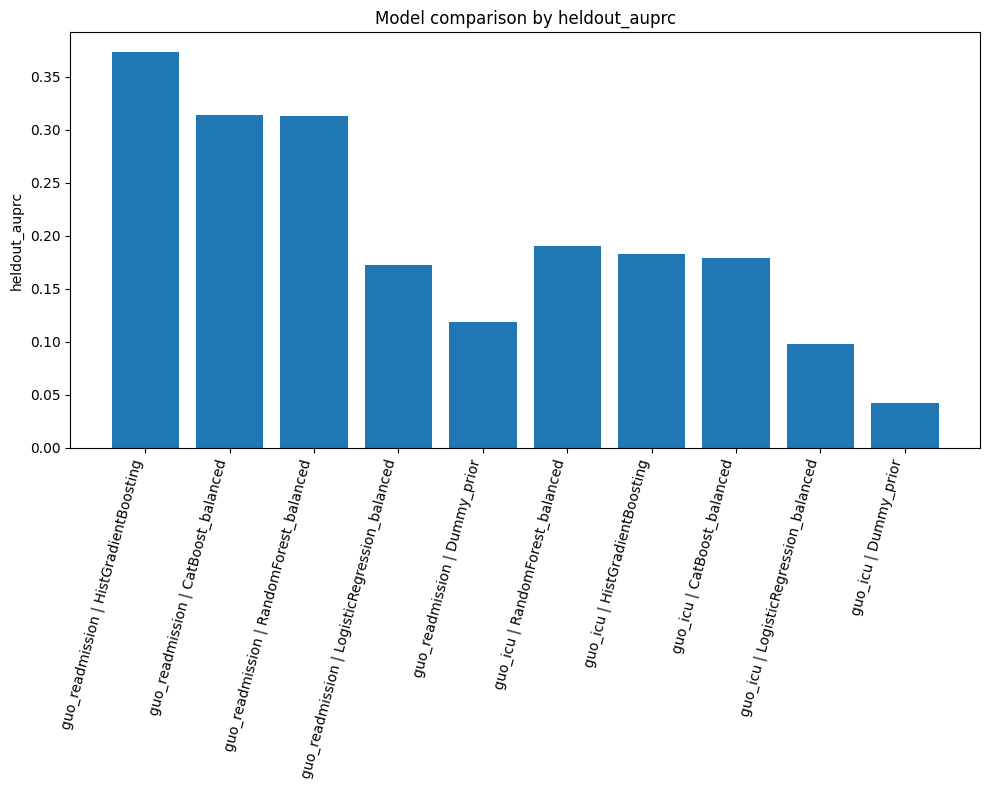

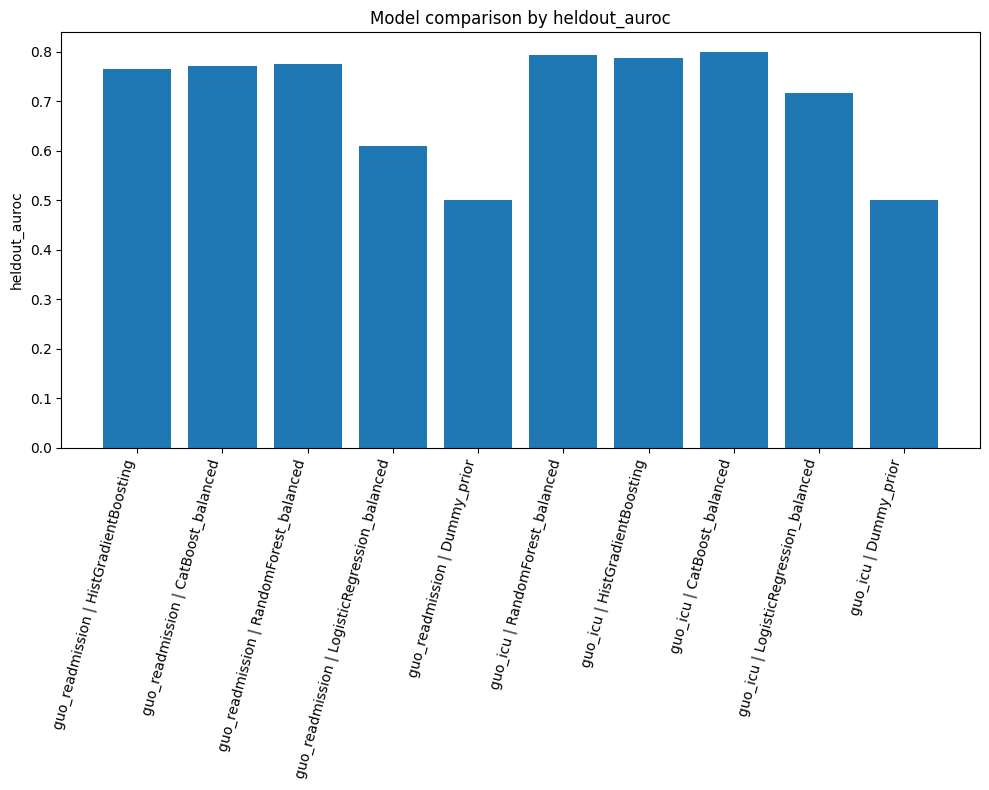

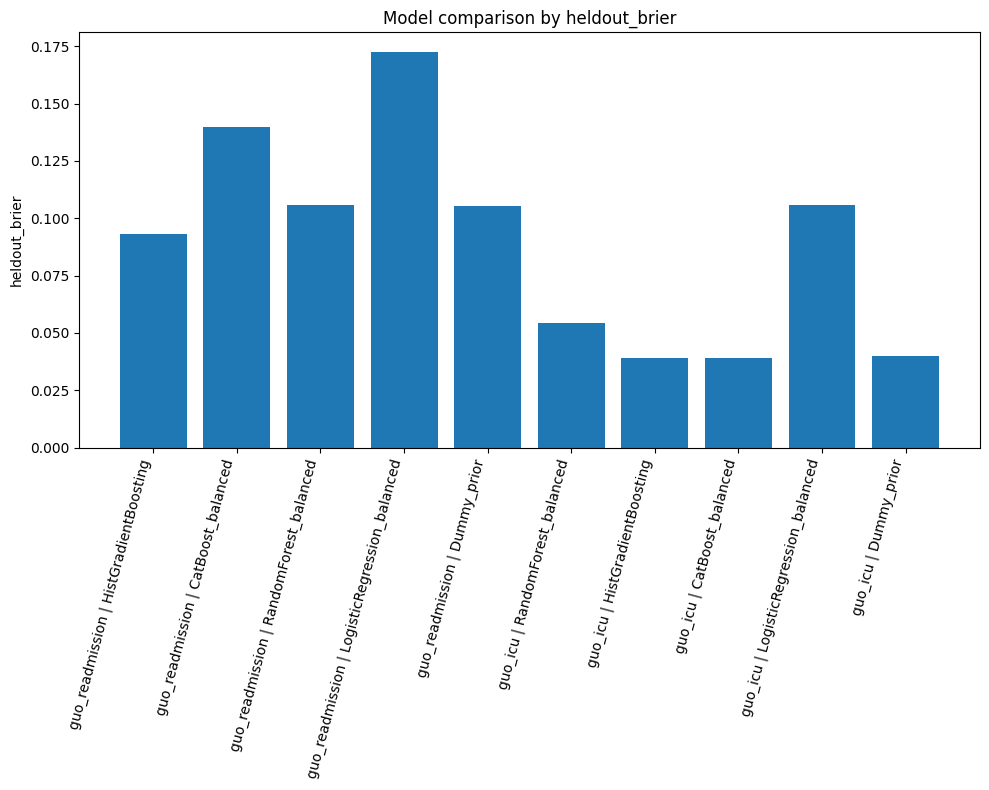

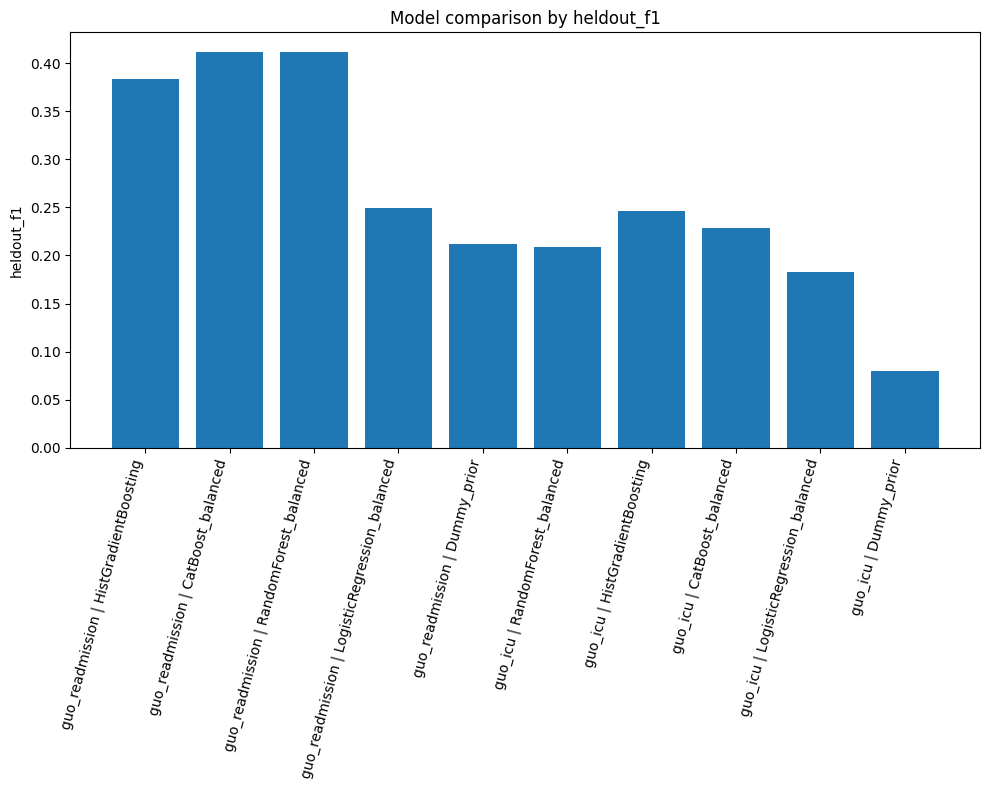

In [15]:
def plot_metric_comparison(results_df: pd.DataFrame, metric: str):
    plt.figure(figsize=(10, 8))

    plot_df = results_df.copy()
    labels = plot_df["task"] + " | " + plot_df["model"]

    plt.bar(labels, plot_df[metric])
    plt.xticks(rotation=75, ha="right")
    plt.ylabel(metric)
    plt.title(f"Model comparison by {metric}")
    plt.tight_layout()
    plt.show()


for metric in ["heldout_auprc", "heldout_auroc", "heldout_brier", "heldout_f1"]:
    plot_metric_comparison(results_df, metric)

## 8.1 Ablation: service/proxy features

Важно понять, какие группы признаков реально дают сигнал и нет ли зависимости от служебных/маршрутных признаков.

Проверяем несколько feature sets:

1. `all_features` — все признаки.
2. `no_service_proxy` — без `CARE_SITE`, `CMS Place of Service`, `Medicare Specialty`.
3. `no_cpt4` — без процедурных `CPT4` признаков.
4. `clinical_only` — только клинические семейства `LOINC`, `SNOMED`, `RxNorm`, `Visit`.

Это не доказывает leakage напрямую, но показывает, насколько качество зависит от потенциально служебных переменных.

In [16]:
SERVICE_PROXY_PATTERNS = [
    "CARE_SITE",
    "CMS_Place_of_Service",
    "Medicare_Specialty",
]

CLINICAL_ONLY_PATTERNS = [
    "LOINC",
    "SNOMED",
    "RxNorm",
    "Visit",
]


def select_ablation_feature_cols(feature_cols: list[str], feature_set: str) -> list[str]:
    if feature_set == "all_features":
        return list(feature_cols)

    if feature_set == "no_service_proxy":
        return [
            c for c in feature_cols
            if not any(pattern in c for pattern in SERVICE_PROXY_PATTERNS)
        ]

    if feature_set == "no_cpt4":
        return [
            c for c in feature_cols
            if "CPT4" not in c
        ]

    if feature_set == "clinical_only":
        # Строгий clinical-only вариант:
        # оставляем только признаки, где явно виден LOINC/SNOMED/RxNorm/Visit.
        # Общие global counts здесь не оставляем, потому что они смешивают все code families.
        return [
            c for c in feature_cols
            if any(pattern in c for pattern in CLINICAL_ONLY_PATTERNS)
        ]

    raise ValueError(f"Unknown feature_set: {feature_set}")


ABLATION_FEATURE_SETS = [
    "all_features",
    "no_service_proxy",
    "no_cpt4",
    "clinical_only",
]

ablation_rows = []
ablation_results = {}

for task_name, df in datasets.items():
    ablation_results[task_name] = {}
    full_feature_cols = feature_cols_by_task[task_name]

    for feature_set in ABLATION_FEATURE_SETS:
        selected_cols = select_ablation_feature_cols(
            feature_cols=full_feature_cols,
            feature_set=feature_set,
        )

        print("\n" + "=" * 100)
        print(f"{task_name} | {feature_set}")
        print("n_features:", len(selected_cols))

        if len(selected_cols) == 0:
            print("No features selected, skipping.")
            continue

        if feature_set == "all_features":
            # Не переобучаем: используем уже посчитанные baseline results.
            res = results_df[results_df["task"] == task_name].copy()
            res["feature_set"] = feature_set
        else:
            res, _, _ = train_and_evaluate_task(
                df=df,
                task_name=f"{task_name}__{feature_set}",
                feature_cols=selected_cols,
                threshold_metric="f1",
            )
            res["feature_set"] = feature_set

        ablation_results[task_name][feature_set] = res
        ablation_rows.append(res)

ablation_results_df = pd.concat(ablation_rows, ignore_index=True)

# Нормализуем task name: убираем суффикс feature_set из task
ablation_results_df["base_task"] = (
    ablation_results_df["task"]
    .str.replace("__no_service_proxy", "", regex=False)
    .str.replace("__no_cpt4", "", regex=False)
    .str.replace("__clinical_only", "", regex=False)
)

ablation_summary_cols = [
    "base_task",
    "feature_set",
    "model",
    "heldout_auroc",
    "heldout_auprc",
    "heldout_brier",
    "heldout_logloss",
    "heldout_f1",
    "heldout_precision",
    "heldout_recall",
    "threshold_selected_on_tuning",
]

ablation_summary_df = (
    ablation_results_df[ablation_summary_cols]
    .sort_values(["base_task", "model", "feature_set"])
    .reset_index(drop=True)
)

display(ablation_summary_df)


guo_readmission | all_features
n_features: 752

guo_readmission | no_service_proxy
n_features: 744

[guo_readmission__no_service_proxy] X_train: (2608, 744)
[guo_readmission__no_service_proxy] X_tuning: (2206, 744)
[guo_readmission__no_service_proxy] X_heldout: (2189, 744)

[guo_readmission__no_service_proxy] Training Dummy_prior...

[guo_readmission__no_service_proxy] Training LogisticRegression_balanced...

[guo_readmission__no_service_proxy] Training RandomForest_balanced...

[guo_readmission__no_service_proxy] Training HistGradientBoosting...

[guo_readmission__no_service_proxy] Training CatBoost_balanced...

guo_readmission | no_cpt4
n_features: 718

[guo_readmission__no_cpt4] X_train: (2608, 718)
[guo_readmission__no_cpt4] X_tuning: (2206, 718)
[guo_readmission__no_cpt4] X_heldout: (2189, 718)

[guo_readmission__no_cpt4] Training Dummy_prior...

[guo_readmission__no_cpt4] Training LogisticRegression_balanced...

[guo_readmission__no_cpt4] Training RandomForest_balanced...

[guo_

,base_task,feature_set,model,heldout_auroc,heldout_auprc,heldout_brier,heldout_logloss,heldout_f1,heldout_precision,heldout_recall,threshold_selected_on_tuning
0,guo_icu,all_features,CatBoost_balanced,0.799265,0.179365,0.039199,0.159837,0.228856,0.198276,0.270588,0.16
1,guo_icu,clinical_only,CatBoost_balanced,0.760758,0.171630,0.041537,0.164363,0.214286,0.161677,0.317647,0.20
2,guo_icu,no_cpt4,CatBoost_balanced,0.800554,0.206943,0.037519,0.158291,0.232558,0.229885,0.235294,0.19
3,guo_icu,no_service_proxy,CatBoost_balanced,0.791713,0.214450,0.041028,0.159404,0.236735,0.181250,0.341176,0.23
4,guo_icu,all_features,Dummy_prior,0.500000,0.041728,0.040015,0.173725,0.080113,0.041728,1.000000,0.01
5,guo_icu,clinical_only,Dummy_prior,0.500000,0.041728,0.040015,0.173725,0.080113,0.041728,1.000000,0.01
6,guo_icu,no_cpt4,Dummy_prior,0.500000,0.041728,0.040015,0.173725,0.080113,0.041728,1.000000,0.01
7,guo_icu,no_service_proxy,Dummy_prior,0.500000,0.041728,0.040015,0.173725,0.080113,0.041728,1.000000,0.01
8,guo_icu,all_features,HistGradientBoosting,0.786506,0.182431,0.038911,0.196132,0.246575,0.201493,0.317647,0.05
9,guo_icu,clinical_only,HistGradientBoosting,0.761481,0.140445,0.039647,0.201393,0.214689,0.206522,0.223529,0.08


In [17]:
# Удобная pivot-таблица по AUPRC: насколько меняется ranking-quality при удалении групп признаков.

ablation_auprc_pivot = (
    ablation_summary_df
    .pivot_table(
        index=["base_task", "model"],
        columns="feature_set",
        values="heldout_auprc",
        aggfunc="first",
    )
    .reset_index()
)

if "all_features" in ablation_auprc_pivot.columns:
    for feature_set in ["no_service_proxy", "no_cpt4", "clinical_only"]:
        if feature_set in ablation_auprc_pivot.columns:
            ablation_auprc_pivot[f"delta_auprc__{feature_set}"] = (
                ablation_auprc_pivot[feature_set]
                - ablation_auprc_pivot["all_features"]
            )

display(
    ablation_auprc_pivot
    .sort_values(["base_task", "all_features"], ascending=[True, False])
)

feature_set,base_task,model,all_features,clinical_only,no_cpt4,no_service_proxy,delta_auprc__no_service_proxy,delta_auprc__no_cpt4,delta_auprc__clinical_only
4,guo_icu,RandomForest_balanced,0.190482,0.156489,0.209763,0.181227,-0.009255,0.019281,-0.033992
2,guo_icu,HistGradientBoosting,0.182431,0.140445,0.162421,0.168561,-0.013870,-0.020010,-0.041986
0,guo_icu,CatBoost_balanced,0.179365,0.171630,0.206943,0.214450,0.035085,0.027578,-0.007735
3,guo_icu,LogisticRegression_balanced,0.097468,0.087826,0.095106,0.099793,0.002325,-0.002362,-0.009642
1,guo_icu,Dummy_prior,0.041728,0.041728,0.041728,0.041728,0.000000,0.000000,0.000000
7,guo_readmission,HistGradientBoosting,0.373410,0.335260,0.354571,0.363664,-0.009746,-0.018838,-0.038149
5,guo_readmission,CatBoost_balanced,0.313687,0.335409,0.324636,0.312876,-0.000811,0.010949,0.021722
9,guo_readmission,RandomForest_balanced,0.313119,0.314145,0.321212,0.321170,0.008051,0.008092,0.001026
8,guo_readmission,LogisticRegression_balanced,0.172881,0.180111,0.172214,0.173726,0.000844,-0.000668,0.007230
6,guo_readmission,Dummy_prior,0.118776,0.118776,0.118776,0.118776,0.000000,0.000000,0.000000


### Выводы

Мы сделали абляцию, чтобы проверить, зависят ли классические модели от потенциально служебных proxy-признаков. Были сравнины четыре набора признаков: все признаки, без служебных/прокси-признаков, без CPT4 признаков и только клинические признаки.

Для `guo_readmission`, удаление служебных/прокси-признаков вызвало лишь небольшое снижение AUPRC для лучшей модели HistGradientBoosting: с 0.373 до 0.364. Версия с только клиническими признаками все равно достигла AUPRC = 0.335, что существенно выше, чем у Dummy baseline AUPRC = 0.119. Это говорит о том, что предсказание повторной госпитализации в основном обусловлено клиническими признаками истории пациента, а не служебными/прокси переменными.

Для `guo_icu`, результаты были более переменными, что ожидаемо, поскольку задача реже встречается. Удаление служебных/прокси-признаков не привело к коллапсу производительности: AUPRC для RandomForest изменился с 0.190 до 0.181, для HistGradientBoosting с 0.182 до 0.169, в то время как CatBoost улучшился с 0.179 до 0.214. Модели с только клиническими признаками также оставались явно выше Dummy baseline, с AUPRC около 0.14–0.17 в зависимости от модели.

В итоге, абляция не показывает доказательств того, что производительность модели обусловлена только утечкой служебных/прокси-признаков. Однако предсказание ICU частично чувствительно к операционным/контекстным признакам, поэтому будущие результаты должны сообщать как о полном наборе признаков, так и о консервативном базовом уровне без служебных/прокси-признаков. Необходимы bootstrap confidence intervals перед тем, как делать сильные утверждения о небольших различиях между наборами признаков.

## ICU парный bootstrap для стабильности абляции

Потому что `guo_icu` имеет только 85 положительных событий на held-out сплите, точечные оценки, такие как AUPRC, могут быть нестабильными. Чтобы проверить, являются ли различия в абляции устойчивыми, мы используем парный bootstrap на held-out примерах.

Это не доказывает и не опровергает утечку напрямую. Оно только проверяет, является ли наблюдаемая разница в метриках между двумя наборами признаков стабильной при ресэмплинге.

Для каждого bootstrap-сэмпла мы ресэмплируем held-out примеры с возвращением и вычисляем:
- AUROC разницу;
- AUPRC разницу;
- top-k precision разницу для top 1%, 5%, 10% и 20% примеров с самым высоким риском.

Мы сравниваем:
- `all_features` vs `no_service_proxy`;
- `all_features` vs `no_cpt4`;
- `all_features` vs `clinical_only`.

Если 95% CI для разницы в метриках включает 0, мы считаем эту разницу нестабильной.

In [18]:
# ICU-only ablation with prediction stores

ICU_TASK = "guo_icu"

ICU_ABLATION_FEATURE_SETS = [
    "all_features",
    "no_service_proxy",
    "no_cpt4",
    "clinical_only",
]

icu_ablation_rows = []
icu_ablation_results = {}
icu_ablation_prediction_store = {}
icu_ablation_fitted_models = {}

icu_df = datasets[ICU_TASK]
icu_full_feature_cols = feature_cols_by_task[ICU_TASK]

for feature_set in ICU_ABLATION_FEATURE_SETS:
    selected_cols = select_ablation_feature_cols(
        feature_cols=icu_full_feature_cols,
        feature_set=feature_set,
    )

    print("\n" + "=" * 100)
    print(f"{ICU_TASK} | {feature_set}")
    print("n_features:", len(selected_cols))

    if len(selected_cols) == 0:
        print("No features selected, skipping.")
        continue

    if feature_set == "all_features":
        # Уже обученные модели и predictions из основного baseline
        res = results_df[results_df["task"] == ICU_TASK].copy()
        res["feature_set"] = feature_set

        icu_ablation_results[feature_set] = res
        icu_ablation_prediction_store[feature_set] = predictions_by_task[ICU_TASK]
        icu_ablation_fitted_models[feature_set] = fitted_models_by_task[ICU_TASK]

    else:
        # Переобучаем только ICU для конкретного feature set
        res, fitted, pred_store = train_and_evaluate_task(
            df=icu_df,
            task_name=f"{ICU_TASK}__{feature_set}",
            feature_cols=selected_cols,
            threshold_metric="f1",
        )

        res["feature_set"] = feature_set

        icu_ablation_results[feature_set] = res
        icu_ablation_prediction_store[feature_set] = pred_store
        icu_ablation_fitted_models[feature_set] = fitted

    icu_ablation_rows.append(res)

icu_ablation_results_df = pd.concat(icu_ablation_rows, ignore_index=True)

icu_ablation_results_df["base_task"] = (
    icu_ablation_results_df["task"]
    .str.replace("__no_service_proxy", "", regex=False)
    .str.replace("__no_cpt4", "", regex=False)
    .str.replace("__clinical_only", "", regex=False)
)

icu_ablation_summary_cols = [
    "base_task",
    "feature_set",
    "model",
    "heldout_auroc",
    "heldout_auprc",
    "heldout_brier",
    "heldout_logloss",
    "heldout_f1",
    "heldout_precision",
    "heldout_recall",
    "threshold_selected_on_tuning",
]

icu_ablation_summary_df = (
    icu_ablation_results_df[icu_ablation_summary_cols]
    .sort_values(["model", "feature_set"])
    .reset_index(drop=True)
)

display(icu_ablation_summary_df)


guo_icu | all_features
n_features: 752

guo_icu | no_service_proxy
n_features: 740

[guo_icu__no_service_proxy] X_train: (2402, 740)
[guo_icu__no_service_proxy] X_tuning: (2052, 740)
[guo_icu__no_service_proxy] X_heldout: (2037, 740)

[guo_icu__no_service_proxy] Training Dummy_prior...

[guo_icu__no_service_proxy] Training LogisticRegression_balanced...

[guo_icu__no_service_proxy] Training RandomForest_balanced...

[guo_icu__no_service_proxy] Training HistGradientBoosting...

[guo_icu__no_service_proxy] Training CatBoost_balanced...

guo_icu | no_cpt4
n_features: 719

[guo_icu__no_cpt4] X_train: (2402, 719)
[guo_icu__no_cpt4] X_tuning: (2052, 719)
[guo_icu__no_cpt4] X_heldout: (2037, 719)

[guo_icu__no_cpt4] Training Dummy_prior...

[guo_icu__no_cpt4] Training LogisticRegression_balanced...

[guo_icu__no_cpt4] Training RandomForest_balanced...

[guo_icu__no_cpt4] Training HistGradientBoosting...

[guo_icu__no_cpt4] Training CatBoost_balanced...

guo_icu | clinical_only
n_features: 66

,base_task,feature_set,model,heldout_auroc,heldout_auprc,heldout_brier,heldout_logloss,heldout_f1,heldout_precision,heldout_recall,threshold_selected_on_tuning
0,guo_icu,all_features,CatBoost_balanced,0.799265,0.179365,0.039199,0.159837,0.228856,0.198276,0.270588,0.16
1,guo_icu,clinical_only,CatBoost_balanced,0.760758,0.171630,0.041537,0.164363,0.214286,0.161677,0.317647,0.20
2,guo_icu,no_cpt4,CatBoost_balanced,0.800554,0.206943,0.037519,0.158291,0.232558,0.229885,0.235294,0.19
3,guo_icu,no_service_proxy,CatBoost_balanced,0.791713,0.214450,0.041028,0.159404,0.236735,0.181250,0.341176,0.23
4,guo_icu,all_features,Dummy_prior,0.500000,0.041728,0.040015,0.173725,0.080113,0.041728,1.000000,0.01
5,guo_icu,clinical_only,Dummy_prior,0.500000,0.041728,0.040015,0.173725,0.080113,0.041728,1.000000,0.01
6,guo_icu,no_cpt4,Dummy_prior,0.500000,0.041728,0.040015,0.173725,0.080113,0.041728,1.000000,0.01
7,guo_icu,no_service_proxy,Dummy_prior,0.500000,0.041728,0.040015,0.173725,0.080113,0.041728,1.000000,0.01
8,guo_icu,all_features,HistGradientBoosting,0.786506,0.182431,0.038911,0.196132,0.246575,0.201493,0.317647,0.05
9,guo_icu,clinical_only,HistGradientBoosting,0.761481,0.140445,0.039647,0.201393,0.214689,0.206522,0.223529,0.08


In [19]:
# Paired bootstrap for ICU ablation differences

from sklearn.metrics import roc_auc_score, average_precision_score


def metric_value(y_true, y_prob, metric: str):
    y_true = np.asarray(y_true)
    y_prob = np.asarray(y_prob)

    if metric == "auroc":
        if len(np.unique(y_true)) < 2:
            return np.nan
        return roc_auc_score(y_true, y_prob)

    if metric == "auprc":
        return average_precision_score(y_true, y_prob)

    raise ValueError(f"Unknown metric: {metric}")


def paired_bootstrap_metric_diff(
    y_true,
    p_a,
    p_b,
    metric: str = "auprc",
    n_bootstrap: int = 2000,
    random_state: int = 42,
):
    """
    Paired bootstrap для разницы метрик.

    delta = metric(A) - metric(B)

    A и B должны быть предсказаниями на одних и тех же held-out examples.
    """
    rng = np.random.default_rng(random_state)

    y_true = np.asarray(y_true)
    p_a = np.asarray(p_a)
    p_b = np.asarray(p_b)

    n = len(y_true)

    original_a = metric_value(y_true, p_a, metric)
    original_b = metric_value(y_true, p_b, metric)
    original_delta = original_a - original_b

    boot_deltas = []

    for _ in range(n_bootstrap):
        idx = rng.integers(0, n, size=n)

        y_boot = y_true[idx]

        # Для AUROC нужен хотя бы один positive и один negative
        if len(np.unique(y_boot)) < 2:
            continue

        m_a = metric_value(y_boot, p_a[idx], metric)
        m_b = metric_value(y_boot, p_b[idx], metric)

        if np.isfinite(m_a) and np.isfinite(m_b):
            boot_deltas.append(m_a - m_b)

    boot_deltas = np.asarray(boot_deltas)

    ci_low, ci_high = np.percentile(boot_deltas, [2.5, 97.5])

    # Осторожный двусторонний bootstrap p-value around zero
    p_left = np.mean(boot_deltas <= 0)
    p_right = np.mean(boot_deltas >= 0)
    p_value = 2 * min(p_left, p_right)
    p_value = min(p_value, 1.0)

    return {
        "metric": metric,
        "metric_a": original_a,
        "metric_b": original_b,
        "delta_a_minus_b": original_delta,
        "delta_ci_low": ci_low,
        "delta_ci_high": ci_high,
        "ci_includes_zero": ci_low <= 0 <= ci_high,
        "bootstrap_p_value": p_value,
        "n_bootstrap_valid": len(boot_deltas),
    }


def get_icu_ablation_probs(feature_set: str, model_name: str):
    """
    Возвращает y_heldout и heldout probabilities для ICU,
    конкретного feature_set и model_name.
    """
    pred_store = icu_ablation_prediction_store[feature_set]

    if model_name not in pred_store:
        raise KeyError(
            f"Model {model_name} not found for feature_set={feature_set}. "
            f"Available models: {list(pred_store.keys())}"
        )

    pred = pred_store[model_name]

    return (
        np.asarray(pred["y_heldout"]),
        np.asarray(pred["heldout_prob"]),
    )

In [20]:
ICU_MODELS_FOR_BOOTSTRAP = [
    "RandomForest_balanced",
    "HistGradientBoosting",
    "CatBoost_balanced",
]

ICU_ABLATION_COMPARISONS = []

for model_name in ICU_MODELS_FOR_BOOTSTRAP:
    for feature_set_b in ["no_service_proxy", "no_cpt4", "clinical_only"]:
        ICU_ABLATION_COMPARISONS.append({
            "task": ICU_TASK,
            "model_a": model_name,
            "feature_set_a": "all_features",
            "model_b": model_name,
            "feature_set_b": feature_set_b,
        })

bootstrap_icu_diff_rows = []

for comp in ICU_ABLATION_COMPARISONS:
    model_a = comp["model_a"]
    model_b = comp["model_b"]
    fs_a = comp["feature_set_a"]
    fs_b = comp["feature_set_b"]

    y_a, p_a = get_icu_ablation_probs(
        feature_set=fs_a,
        model_name=model_a,
    )

    y_b, p_b = get_icu_ablation_probs(
        feature_set=fs_b,
        model_name=model_b,
    )

    assert np.array_equal(y_a, y_b), (
        f"Held-out labels are not aligned for {model_a}: {fs_a} vs {fs_b}"
    )

    for metric in ["auroc", "auprc"]:
        out = paired_bootstrap_metric_diff(
            y_true=y_a,
            p_a=p_a,
            p_b=p_b,
            metric=metric,
            n_bootstrap=2000,
            random_state=RANDOM_STATE,
        )

        out.update({
            "task": ICU_TASK,
            "model_a": model_a,
            "feature_set_a": fs_a,
            "model_b": model_b,
            "feature_set_b": fs_b,
        })

        bootstrap_icu_diff_rows.append(out)

bootstrap_icu_diff_df = pd.DataFrame(bootstrap_icu_diff_rows)

bootstrap_icu_diff_display_cols = [
    "task",
    "metric",
    "model_a",
    "feature_set_a",
    "model_b",
    "feature_set_b",
    "metric_a",
    "metric_b",
    "delta_a_minus_b",
    "delta_ci_low",
    "delta_ci_high",
    "ci_includes_zero",
    "bootstrap_p_value",
    "n_bootstrap_valid",
]

display(
    bootstrap_icu_diff_df[bootstrap_icu_diff_display_cols]
    .sort_values(["model_a", "metric", "feature_set_b"])
)

,task,metric,model_a,feature_set_a,model_b,feature_set_b,metric_a,metric_b,delta_a_minus_b,delta_ci_low,delta_ci_high,ci_includes_zero,bootstrap_p_value,n_bootstrap_valid
17,guo_icu,auprc,CatBoost_balanced,all_features,CatBoost_balanced,clinical_only,0.179365,0.171630,0.007735,-0.044993,0.063650,True,0.746,2000
15,guo_icu,auprc,CatBoost_balanced,all_features,CatBoost_balanced,no_cpt4,0.179365,0.206943,-0.027578,-0.086937,0.016374,True,0.224,2000
13,guo_icu,auprc,CatBoost_balanced,all_features,CatBoost_balanced,no_service_proxy,0.179365,0.214450,-0.035085,-0.079336,0.009812,True,0.150,2000
16,guo_icu,auroc,CatBoost_balanced,all_features,CatBoost_balanced,clinical_only,0.799265,0.760758,0.038507,0.005309,0.070914,False,0.028,2000
14,guo_icu,auroc,CatBoost_balanced,all_features,CatBoost_balanced,no_cpt4,0.799265,0.800554,-0.001290,-0.026217,0.023574,True,0.891,2000
12,guo_icu,auroc,CatBoost_balanced,all_features,CatBoost_balanced,no_service_proxy,0.799265,0.791713,0.007552,-0.019748,0.033376,True,0.605,2000
11,guo_icu,auprc,HistGradientBoosting,all_features,HistGradientBoosting,clinical_only,0.182431,0.140445,0.041986,-0.023842,0.107870,True,0.193,2000
9,guo_icu,auprc,HistGradientBoosting,all_features,HistGradientBoosting,no_cpt4,0.182431,0.162421,0.020010,-0.017389,0.065824,True,0.331,2000
7,guo_icu,auprc,HistGradientBoosting,all_features,HistGradientBoosting,no_service_proxy,0.182431,0.168561,0.013870,-0.020969,0.055333,True,0.457,2000
10,guo_icu,auroc,HistGradientBoosting,all_features,HistGradientBoosting,clinical_only,0.786506,0.761481,0.025024,-0.006584,0.057718,True,0.123,2000


In [21]:
icu_auprc_bootstrap_summary = (
    bootstrap_icu_diff_df
    .query("metric == 'auprc'")
    [[
        "model_a",
        "feature_set_a",
        "feature_set_b",
        "metric_a",
        "metric_b",
        "delta_a_minus_b",
        "delta_ci_low",
        "delta_ci_high",
        "ci_includes_zero",
        "bootstrap_p_value",
    ]]
    .rename(columns={
        "model_a": "model",
        "feature_set_a": "A",
        "feature_set_b": "B",
        "metric_a": "A_auprc",
        "metric_b": "B_auprc",
        "delta_a_minus_b": "delta_auprc_A_minus_B",
    })
    .sort_values(["model", "B"])
)

display(icu_auprc_bootstrap_summary)

,model,A,B,A_auprc,B_auprc,delta_auprc_A_minus_B,delta_ci_low,delta_ci_high,ci_includes_zero,bootstrap_p_value
17,CatBoost_balanced,all_features,clinical_only,0.179365,0.171630,0.007735,-0.044993,0.063650,True,0.746
15,CatBoost_balanced,all_features,no_cpt4,0.179365,0.206943,-0.027578,-0.086937,0.016374,True,0.224
13,CatBoost_balanced,all_features,no_service_proxy,0.179365,0.214450,-0.035085,-0.079336,0.009812,True,0.150
11,HistGradientBoosting,all_features,clinical_only,0.182431,0.140445,0.041986,-0.023842,0.107870,True,0.193
9,HistGradientBoosting,all_features,no_cpt4,0.182431,0.162421,0.020010,-0.017389,0.065824,True,0.331
7,HistGradientBoosting,all_features,no_service_proxy,0.182431,0.168561,0.013870,-0.020969,0.055333,True,0.457
5,RandomForest_balanced,all_features,clinical_only,0.190482,0.156489,0.033992,-0.008632,0.080853,True,0.122
3,RandomForest_balanced,all_features,no_cpt4,0.190482,0.209763,-0.019281,-0.052519,0.015899,True,0.317
1,RandomForest_balanced,all_features,no_service_proxy,0.190482,0.181227,0.009255,-0.013148,0.034771,True,0.401


### Результаты

Для ICU transfer prediction, мы использовали парный bootstrap на held-out сплите, чтобы проверить, являются ли различия в AUPRC между `all_features` и абляционными наборами признаков стабильными. Сравнивались следующие абляции: `no_service_proxy`, `no_cpt4` и `clinical_only`.

Среди RandomForest, HistGradientBoosting и CatBoost, все 95% confidence intervals для различий в AUPRC включали ноль. Поэтому наблюдаемые различия в AUPRC между полным и абляционными наборами признаков не были статистически стабильными при bootstrap. 

Это означает, что у нас нет доказательств того, что производительность модели ICU критически зависит от служебных/прокси признаков, таких как CARE_SITE, CMS Place of Service, Medicare Specialty или CPT4. Некоторые точечные оценки изменились после удаления этих признаков, но различия недостаточно устойчивы, чтобы утверждать о стабильном эффекте.

Это не доказывает, что утечка невозможна, но это говорит о том, что текущий ICU baseline не явно обусловлен утечкой служебных/прокси признаков. Учитывая небольшое количество положительных ICU событий на held-out, эти результаты абляции все равно следует интерпретировать с осторожностью.

## 8.2 Time boundary sensitivity: `<` vs `<= prediction_time`

В основной версии признаки строятся по условию:

```text
event.time <= prediction_time
```

Для `guo_readmission` это обычно оправдано, если `prediction_time` соответствует концу дня выписки: события в этот момент являются частью информации, доступной на момент выписки.

Для `guo_icu` это рискованнее: часть событий в день admission может уже отражать раннее ухудшение или текущий маршрут пациента. Поэтому дополнительно прогоняем sensitivity-вариант:

```text
event.time < prediction_time
```

Если качество сильно падает, значит значительная часть сигнала находится ровно в `prediction_time`, и это нужно отдельно обосновывать.

In [22]:
STRICT_CUTOFF_TASKS = [
    "guo_icu",
    "guo_readmission",
]

strict_cutoff_datasets = {}
strict_cutoff_feature_cols_by_task = {}
strict_cutoff_results = []

for task_name in STRICT_CUTOFF_TASKS:
    print("\n" + "=" * 100)
    print(f"Building strict cutoff dataset for {task_name}: event.time < prediction_time")

    strict_df = build_features_for_task(
        task_name=task_name,
        labels=labels_by_task[task_name],
        top_n_codes=TOP_N_CODES,
        top_n_numeric_codes=TOP_N_NUMERIC_CODES,
        lookback_days=LOOKBACK_DAYS,
        use_cache=True,
        include_prediction_time=False,
    )

    strict_cutoff_datasets[task_name] = strict_df

    _, strict_feature_cols = dataset_sanity_check(
        df=strict_df,
        task_name=f"{task_name}__lt_prediction_time",
    )
    strict_cutoff_feature_cols_by_task[task_name] = strict_feature_cols

    res, _, _ = train_and_evaluate_task(
        df=strict_df,
        task_name=f"{task_name}__lt_prediction_time",
        feature_cols=strict_feature_cols,
        threshold_metric="f1",
    )

    strict_cutoff_results.append(res)

strict_cutoff_results_df = pd.concat(strict_cutoff_results, ignore_index=True)

display(
    strict_cutoff_results_df[[
        "task",
        "model",
        "heldout_auroc",
        "heldout_auprc",
        "heldout_brier",
        "heldout_logloss",
        "heldout_f1",
        "heldout_precision",
        "heldout_recall",
        "threshold_selected_on_tuning",
    ]]
    .sort_values(["task", "heldout_auprc"], ascending=[True, False])
)


Building strict cutoff dataset for guo_icu: event.time < prediction_time
[guo_icu] Loading cached features: ehrshot_baseline_cache/guo_icu_lt_prediction_time_features_top500_num40.parquet

guo_icu__lt_prediction_time
shape: (6491, 757)
n_features: 751
label nulls: 0
split nulls: 0


,split,n_examples,n_patients,n_positive,event_rate,event_rate_percent
0,held_out,2037,1154,85,0.041728,4.172803
1,train,2402,1306,113,0.047044,4.704413
2,tuning,2052,1157,92,0.044834,4.483431



[guo_icu__lt_prediction_time] X_train: (2402, 751)
[guo_icu__lt_prediction_time] X_tuning: (2052, 751)
[guo_icu__lt_prediction_time] X_heldout: (2037, 751)

[guo_icu__lt_prediction_time] Training Dummy_prior...

[guo_icu__lt_prediction_time] Training LogisticRegression_balanced...

[guo_icu__lt_prediction_time] Training RandomForest_balanced...

[guo_icu__lt_prediction_time] Training HistGradientBoosting...

[guo_icu__lt_prediction_time] Training CatBoost_balanced...

Building strict cutoff dataset for guo_readmission: event.time < prediction_time
[guo_readmission] Loading cached features: ehrshot_baseline_cache/guo_readmission_lt_prediction_time_features_top500_num40.parquet

guo_readmission__lt_prediction_time
shape: (7003, 758)
n_features: 752
label nulls: 0
split nulls: 0


,split,n_examples,n_patients,n_positive,event_rate,event_rate_percent
0,held_out,2189,1190,260,0.118776,11.877570
1,train,2608,1337,370,0.141871,14.187117
2,tuning,2206,1191,281,0.127380,12.737987



[guo_readmission__lt_prediction_time] X_train: (2608, 752)
[guo_readmission__lt_prediction_time] X_tuning: (2206, 752)
[guo_readmission__lt_prediction_time] X_heldout: (2189, 752)

[guo_readmission__lt_prediction_time] Training Dummy_prior...

[guo_readmission__lt_prediction_time] Training LogisticRegression_balanced...

[guo_readmission__lt_prediction_time] Training RandomForest_balanced...

[guo_readmission__lt_prediction_time] Training HistGradientBoosting...

[guo_readmission__lt_prediction_time] Training CatBoost_balanced...


,task,model,heldout_auroc,heldout_auprc,heldout_brier,heldout_logloss,heldout_f1,heldout_precision,heldout_recall,threshold_selected_on_tuning
0,guo_icu__lt_prediction_time,CatBoost_balanced,0.795004,0.200539,0.044884,0.170720,0.230508,0.161905,0.400000,0.24
1,guo_icu__lt_prediction_time,RandomForest_balanced,0.794286,0.199673,0.053748,0.223070,0.227273,0.219780,0.235294,0.38
2,guo_icu__lt_prediction_time,HistGradientBoosting,0.802730,0.176462,0.039336,0.188299,0.248848,0.204545,0.317647,0.05
3,guo_icu__lt_prediction_time,LogisticRegression_balanced,0.702971,0.091056,0.111027,0.594717,0.174672,0.138889,0.235294,0.83
4,guo_icu__lt_prediction_time,Dummy_prior,0.500000,0.041728,0.040015,0.173725,0.080113,0.041728,1.000000,0.01
5,guo_readmission__lt_prediction_time,HistGradientBoosting,0.766424,0.378467,0.092857,0.356047,0.405546,0.369085,0.450000,0.11
6,guo_readmission__lt_prediction_time,RandomForest_balanced,0.779796,0.313566,0.104914,0.355844,0.414911,0.358543,0.492308,0.39
7,guo_readmission__lt_prediction_time,CatBoost_balanced,0.765888,0.300749,0.129537,0.419526,0.414566,0.325991,0.569231,0.44
8,guo_readmission__lt_prediction_time,LogisticRegression_balanced,0.599288,0.172038,0.174971,0.912773,0.259777,0.203947,0.357692,0.38
9,guo_readmission__lt_prediction_time,Dummy_prior,0.500000,0.118776,0.105201,0.366778,0.212332,0.118776,1.000000,0.01


In [23]:
# Сравнение основной версии <= prediction_time и strict версии < prediction_time.

strict_compare = strict_cutoff_results_df.copy()
strict_compare["base_task"] = strict_compare["task"].str.replace("__lt_prediction_time", "", regex=False)
strict_compare["cutoff"] = "time < prediction_time"

main_compare = results_df[
    results_df["task"].isin(STRICT_CUTOFF_TASKS)
].copy()
main_compare["base_task"] = main_compare["task"]
main_compare["cutoff"] = "time <= prediction_time"

cutoff_comparison_df = pd.concat([main_compare, strict_compare], ignore_index=True)

cutoff_comparison_cols = [
    "base_task",
    "cutoff",
    "model",
    "heldout_auroc",
    "heldout_auprc",
    "heldout_brier",
    "heldout_logloss",
    "heldout_f1",
    "heldout_precision",
    "heldout_recall",
]

display(
    cutoff_comparison_df[cutoff_comparison_cols]
    .sort_values(["base_task", "model", "cutoff"])
)

cutoff_auprc_pivot = (
    cutoff_comparison_df
    .pivot_table(
        index=["base_task", "model"],
        columns="cutoff",
        values="heldout_auprc",
        aggfunc="first",
    )
    .reset_index()
)

if "time <= prediction_time" in cutoff_auprc_pivot.columns and "time < prediction_time" in cutoff_auprc_pivot.columns:
    cutoff_auprc_pivot["delta_auprc_strict_minus_main"] = (
        cutoff_auprc_pivot["time < prediction_time"]
        - cutoff_auprc_pivot["time <= prediction_time"]
    )

display(cutoff_auprc_pivot)

,base_task,cutoff,model,heldout_auroc,heldout_auprc,heldout_brier,heldout_logloss,heldout_f1,heldout_precision,heldout_recall
10,guo_icu,time < prediction_time,CatBoost_balanced,0.795004,0.200539,0.044884,0.170720,0.230508,0.161905,0.400000
7,guo_icu,time <= prediction_time,CatBoost_balanced,0.799265,0.179365,0.039199,0.159837,0.228856,0.198276,0.270588
14,guo_icu,time < prediction_time,Dummy_prior,0.500000,0.041728,0.040015,0.173725,0.080113,0.041728,1.000000
9,guo_icu,time <= prediction_time,Dummy_prior,0.500000,0.041728,0.040015,0.173725,0.080113,0.041728,1.000000
12,guo_icu,time < prediction_time,HistGradientBoosting,0.802730,0.176462,0.039336,0.188299,0.248848,0.204545,0.317647
6,guo_icu,time <= prediction_time,HistGradientBoosting,0.786506,0.182431,0.038911,0.196132,0.246575,0.201493,0.317647
13,guo_icu,time < prediction_time,LogisticRegression_balanced,0.702971,0.091056,0.111027,0.594717,0.174672,0.138889,0.235294
8,guo_icu,time <= prediction_time,LogisticRegression_balanced,0.717231,0.097468,0.105798,0.561534,0.182456,0.130000,0.305882
11,guo_icu,time < prediction_time,RandomForest_balanced,0.794286,0.199673,0.053748,0.223070,0.227273,0.219780,0.235294
5,guo_icu,time <= prediction_time,RandomForest_balanced,0.793750,0.190482,0.054363,0.222534,0.208835,0.158537,0.305882


cutoff,base_task,model,time < prediction_time,time <= prediction_time,delta_auprc_strict_minus_main
0,guo_icu,CatBoost_balanced,0.200539,0.179365,0.021174
1,guo_icu,Dummy_prior,0.041728,0.041728,0.000000
2,guo_icu,HistGradientBoosting,0.176462,0.182431,-0.005969
3,guo_icu,LogisticRegression_balanced,0.091056,0.097468,-0.006411
4,guo_icu,RandomForest_balanced,0.199673,0.190482,0.009191
5,guo_readmission,CatBoost_balanced,0.300749,0.313687,-0.012939
6,guo_readmission,Dummy_prior,0.118776,0.118776,0.000000
7,guo_readmission,HistGradientBoosting,0.378467,0.373410,0.005057
8,guo_readmission,LogisticRegression_balanced,0.172038,0.172881,-0.000843
9,guo_readmission,RandomForest_balanced,0.313566,0.313119,0.000447


Sensitivity analysis со строгой границей time < prediction_time не показал признаков того, что качество модели держится на событиях, происходящих ровно в prediction_time.

### Проверка возможной утечки в `guo_icu`

Мы попытались найти явное событие перевода в ICU внутри MEDS timeline через metadata кодов и события после `prediction_time` у positive ICU labels. Однако descriptions для relevant local/service codes пустые, поэтому точное время ICU transfer нельзя надежно восстановить только из MEDS metadata.

По официальному описанию EHRSHOT, задача `ICU Transfer` формулируется как предсказание того, будет ли пациент переведен в ICU во время текущей госпитализации. `prediction_time` задан как 23:59 в день admission, горизонт прогноза — длительность admission, а ICU transfers, произошедшие в тот же день admission, игнорируются. Поэтому случаи, где ICU transfer уже произошел в день admission до `prediction_time`, не должны попадать в positive labels.

Дополнительно мы провели sensitivity analysis для границы времени: сравнили признаки, построенные по `time <= prediction_time`, и более строгий вариант `time < prediction_time`. Переход к строгому cutoff не привел к систематическому падению AUPRC для ICU, поэтому нет признаков того, что качество модели держится на событиях ровно в `prediction_time`.

## 9. ROC and PR curves

Для дисбалансных задач PR curve обычно информативнее ROC curve.

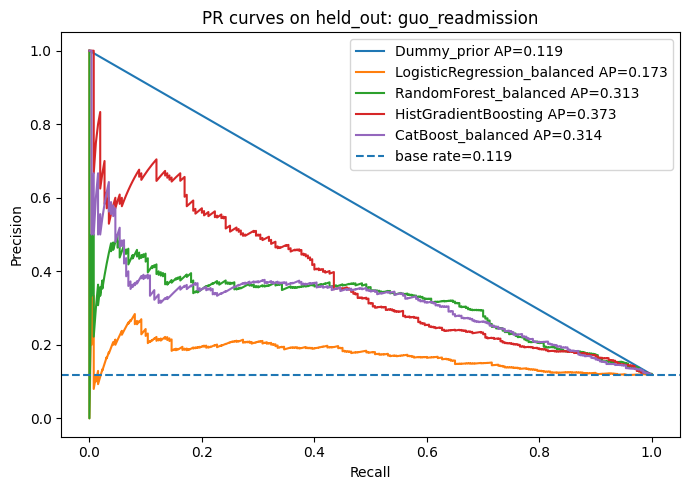

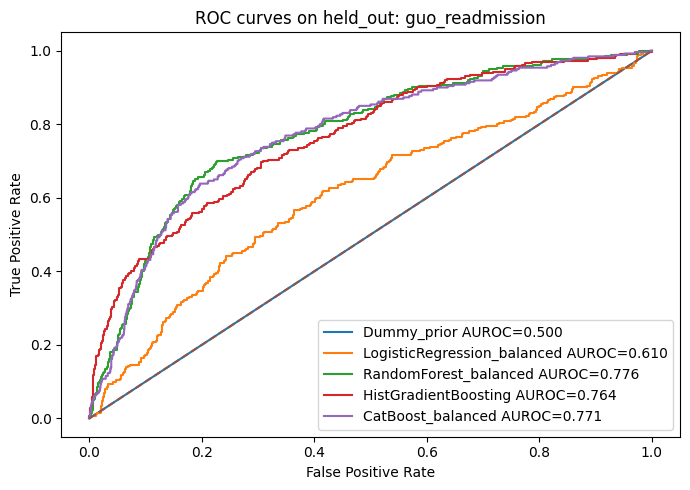

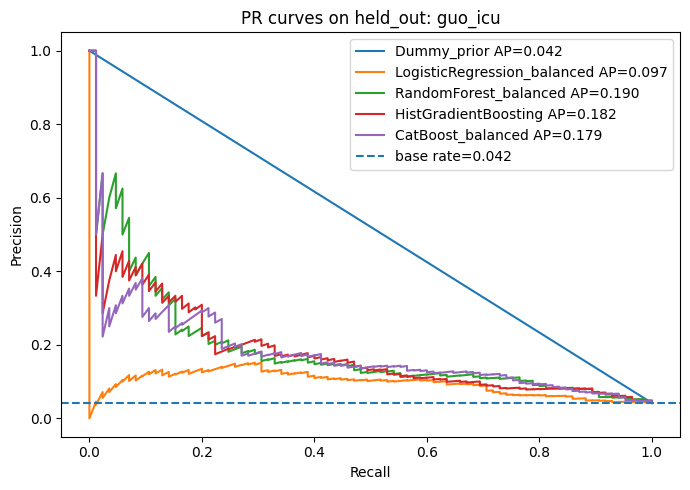

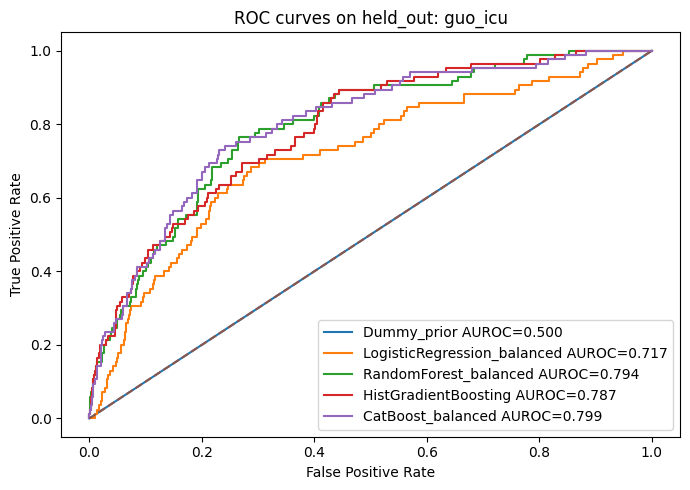

In [24]:
def plot_curves_for_task(task_name: str):
    pred_store = predictions_by_task[task_name]

    # PR curves
    plt.figure(figsize=(7, 5))
    for model_name, pred in pred_store.items():
        precision, recall, _ = precision_recall_curve(
            pred["y_heldout"],
            pred["heldout_prob"],
        )
        ap = average_precision_score(pred["y_heldout"], pred["heldout_prob"])
        plt.plot(recall, precision, label=f"{model_name} AP={ap:.3f}")

    base_rate = np.mean(next(iter(pred_store.values()))["y_heldout"])
    plt.axhline(base_rate, linestyle="--", label=f"base rate={base_rate:.3f}")

    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"PR curves on held_out: {task_name}")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # ROC curves
    plt.figure(figsize=(7, 5))
    for model_name, pred in pred_store.items():
        fpr, tpr, _ = roc_curve(pred["y_heldout"], pred["heldout_prob"])
        auc = roc_auc_score(pred["y_heldout"], pred["heldout_prob"])
        plt.plot(fpr, tpr, label=f"{model_name} AUROC={auc:.3f}")

    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC curves on held_out: {task_name}")
    plt.legend()
    plt.tight_layout()
    plt.show()


for task_name in datasets:
    plot_curves_for_task(task_name)

## 10. Calibration check

Brier score уже есть в таблице, но дополнительно смотрим calibration curve.

Если модель плохо калибрована, можно позже добавить:

- Platt scaling / `CalibratedClassifierCV`;
- isotonic calibration;
- отдельную calibration модель на tuning split.

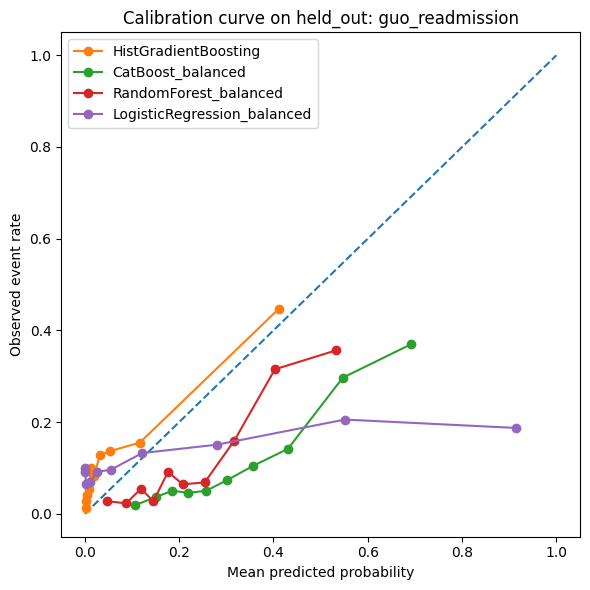

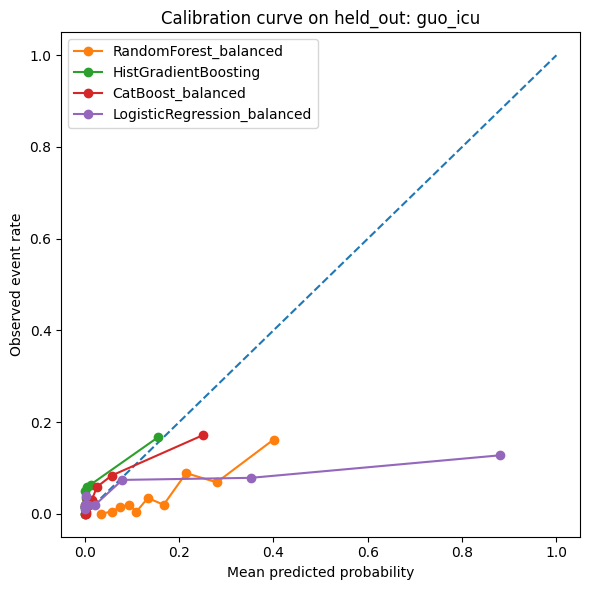

In [25]:
def calibration_table(y_true, y_prob, n_bins: int = 10):
    df = pd.DataFrame({
        "y_true": y_true,
        "y_prob": y_prob,
    })
    df["bin"] = pd.qcut(df["y_prob"], q=n_bins, duplicates="drop")

    out = (
        df.groupby("bin", observed=True)
        .agg(
            n=("y_true", "size"),
            mean_pred=("y_prob", "mean"),
            observed_rate=("y_true", "mean"),
        )
        .reset_index(drop=True)
    )

    return out


def plot_calibration_for_task(task_name: str, top_k_models: int = 4):
    # Берем top-k моделей по AUPRC для читаемости
    top_models = (
        results_df[results_df["task"] == task_name]
        .sort_values("heldout_auprc", ascending=False)
        .head(top_k_models)["model"]
        .tolist()
    )

    plt.figure(figsize=(6, 6))
    plt.plot([0, 1], [0, 1], linestyle="--")

    for model_name in top_models:
        pred = predictions_by_task[task_name][model_name]
        cal = calibration_table(pred["y_heldout"], pred["heldout_prob"], n_bins=10)
        plt.plot(cal["mean_pred"], cal["observed_rate"], marker="o", label=model_name)

    plt.xlabel("Mean predicted probability")
    plt.ylabel("Observed event rate")
    plt.title(f"Calibration curve on held_out: {task_name}")
    plt.legend()
    plt.tight_layout()
    plt.show()


for task_name in datasets:
    plot_calibration_for_task(task_name)

## 10.1 Probability calibration on tuning split

Предыдущие calibration curves показали, что сырые вероятности моделей не идеально откалиброваны. Это ожидаемо, потому что несколько моделей обучались с балансировкой классов. Балансировка классов помогает модели обнаруживать редкие положительные случаи, но получающиеся вероятности могут уже не соответствовать истинным вероятностям событий.

Калибровка нужна, когда мы хотим интерпретировать выходы модели как risk scores. Хорошо откалиброванная модель должна удовлетворять следующему свойству: среди пациентов, которым предсказан риск около 0.30, примерно 30% должны действительно испытать событие.

Мы используем следующий протокол:
1. Тренируем базовую модель на `train`.
2. Предсказываем вероятности на `tuning`.
3. Обучаем calibrator на предсказаниях и метках `tuning`.
4. Применяем calibrator к предсказаниям на `held_out`.
5. Сравниваем сырые и откалиброванные вероятности на `held_out`.

Мы тестируем два метода калибровки:
- **Platt scaling:** логистическая регрессия на вероятностях/логитах модели.
- **Isotonic regression:** гибкая монотонная калибровка.

Для редких событий, таких как `guo_icu`, Platt scaling обычно безопаснее, потому что isotonic regression может переобучиться, когда количество положительных примеров мало.

In [26]:
from sklearn.linear_model import LogisticRegression
from sklearn.isotonic import IsotonicRegression


def clip_proba(p, eps: float = 1e-6):
    return np.clip(np.asarray(p), eps, 1 - eps)


def logit(p):
    p = clip_proba(p)
    return np.log(p / (1 - p))


def fit_platt_calibrator(y_calib, p_calib):
    """
    Platt scaling:
    обучаем Logistic Regression на logit(raw_probability) -> y.

    Важно:
    - calibrator обучается только на tuning split;
    - class_weight не используем, потому что хотим восстановить реальные вероятности,
      а не балансировать классы.
    """
    x_calib = logit(p_calib).reshape(-1, 1)

    calibrator = LogisticRegression(
        solver="lbfgs",
        max_iter=1000,
        random_state=RANDOM_STATE,
    )
    calibrator.fit(x_calib, y_calib)

    def transform(p):
        x = logit(p).reshape(-1, 1)
        return calibrator.predict_proba(x)[:, 1]

    return transform, calibrator


def fit_isotonic_calibrator(y_calib, p_calib):
    """
    Isotonic regression:
    гибкая монотонная калибровка raw probabilities -> calibrated probabilities.
    """
    calibrator = IsotonicRegression(
        y_min=0.0,
        y_max=1.0,
        out_of_bounds="clip",
    )
    calibrator.fit(p_calib, y_calib)

    def transform(p):
        return calibrator.predict(clip_proba(p))

    return transform, calibrator


def evaluate_raw_and_calibrated_predictions(
    task_name: str,
    model_name: str,
    threshold_metric: str = "f1",
):
    """
    Для выбранной модели:
    - берет raw probabilities на tuning и held_out;
    - обучает Platt и Isotonic calibrators на tuning;
    - применяет к held_out;
    - пересчитывает threshold на tuning после calibration;
    - возвращает метрики raw / platt / isotonic.
    """
    pred = predictions_by_task[task_name][model_name]

    y_tuning = pred["y_tuning"]
    p_tuning_raw = pred["tuning_prob"]

    y_heldout = pred["y_heldout"]
    p_heldout_raw = pred["heldout_prob"]

    calibration_methods = {}

    # Raw probabilities
    calibration_methods["raw"] = {
        "transform": lambda p: p,
        "calibrator": None,
    }

    # Platt scaling
    platt_transform, platt_calibrator = fit_platt_calibrator(
        y_calib=y_tuning,
        p_calib=p_tuning_raw,
    )
    calibration_methods["platt"] = {
        "transform": platt_transform,
        "calibrator": platt_calibrator,
    }

    # Isotonic regression
    isotonic_transform, isotonic_calibrator = fit_isotonic_calibrator(
        y_calib=y_tuning,
        p_calib=p_tuning_raw,
    )
    calibration_methods["isotonic"] = {
        "transform": isotonic_transform,
        "calibrator": isotonic_calibrator,
    }

    rows = []
    calibrated_predictions = {}

    for calibration_name, obj in calibration_methods.items():
        transform = obj["transform"]

        p_tuning = transform(p_tuning_raw)
        p_heldout = transform(p_heldout_raw)

        threshold, threshold_score = choose_threshold(
            y_true=y_tuning,
            y_prob=p_tuning,
            metric=threshold_metric,
        )

        tuning_metrics = evaluate_predictions(
            y_true=y_tuning,
            y_prob=p_tuning,
            threshold=threshold,
        )

        heldout_metrics = evaluate_predictions(
            y_true=y_heldout,
            y_prob=p_heldout,
            threshold=threshold,
        )

        row = {
            "task": task_name,
            "model": model_name,
            "calibration": calibration_name,
            "threshold_metric": threshold_metric,
            "threshold_selected_on_tuning": threshold,
            "threshold_score_on_tuning": threshold_score,
        }

        for k, v in tuning_metrics.items():
            row[f"tuning_{k}"] = v

        for k, v in heldout_metrics.items():
            row[f"heldout_{k}"] = v

        rows.append(row)

        calibrated_predictions[calibration_name] = {
            "y_tuning": y_tuning,
            "p_tuning": p_tuning,
            "y_heldout": y_heldout,
            "p_heldout": p_heldout,
            "threshold": threshold,
            "calibrator": obj["calibrator"],
        }

    return pd.DataFrame(rows), calibrated_predictions

In [27]:
CALIBRATION_MODELS = {
    "guo_readmission": [
        "HistGradientBoosting",
    ],
    "guo_icu": [
        "HistGradientBoosting",
        "RandomForest_balanced",
    ],
}

calibration_results = []
calibrated_predictions_by_task = {}

for task_name, model_names in CALIBRATION_MODELS.items():
    calibrated_predictions_by_task[task_name] = {}

    for model_name in model_names:
        print("\n" + "=" * 100)
        print(f"Calibrating {task_name} | {model_name}")

        cal_df, cal_preds = evaluate_raw_and_calibrated_predictions(
            task_name=task_name,
            model_name=model_name,
            threshold_metric="f1",
        )

        calibration_results.append(cal_df)
        calibrated_predictions_by_task[task_name][model_name] = cal_preds

calibration_results_df = pd.concat(calibration_results, ignore_index=True)

calibration_metric_cols = [
    "task",
    "model",
    "calibration",
    "heldout_auroc",
    "heldout_auprc",
    "heldout_brier",
    "heldout_logloss",
    "heldout_f1",
    "heldout_precision",
    "heldout_recall",
    "heldout_balanced_accuracy",
    "heldout_predicted_positive_rate",
    "threshold_selected_on_tuning",
]

display(
    calibration_results_df[calibration_metric_cols]
    .sort_values(["task", "model", "heldout_brier"])
)


Calibrating guo_readmission | HistGradientBoosting

Calibrating guo_icu | HistGradientBoosting

Calibrating guo_icu | RandomForest_balanced


,task,model,calibration,heldout_auroc,heldout_auprc,heldout_brier,heldout_logloss,heldout_f1,heldout_precision,heldout_recall,heldout_balanced_accuracy,heldout_predicted_positive_rate,threshold_selected_on_tuning
4,guo_icu,HistGradientBoosting,platt,0.786506,0.182431,0.037824,0.151863,0.200000,0.180952,0.223529,0.589736,0.051546,0.17
5,guo_icu,HistGradientBoosting,isotonic,0.783082,0.144893,0.038414,0.155903,0.200000,0.180952,0.223529,0.589736,0.051546,0.15
3,guo_icu,HistGradientBoosting,raw,0.786506,0.182431,0.038911,0.196132,0.246575,0.201493,0.317647,0.631416,0.065783,0.05
7,guo_icu,RandomForest_balanced,platt,0.793750,0.190482,0.037697,0.150245,0.215385,0.190909,0.247059,0.600732,0.054001,0.19
8,guo_icu,RandomForest_balanced,isotonic,0.789817,0.152339,0.038064,0.162638,0.214286,0.189189,0.247059,0.600476,0.054492,0.15
6,guo_icu,RandomForest_balanced,raw,0.793750,0.190482,0.054363,0.222534,0.208835,0.158537,0.305882,0.617593,0.080511,0.34
1,guo_readmission,HistGradientBoosting,platt,0.764336,0.373410,0.090315,0.311460,0.400000,0.352941,0.461538,0.673745,0.155322,0.20
2,guo_readmission,HistGradientBoosting,isotonic,0.759936,0.334709,0.091242,0.325607,0.398682,0.348703,0.465385,0.674113,0.158520,0.20
0,guo_readmission,HistGradientBoosting,raw,0.764336,0.373410,0.093031,0.358920,0.383929,0.313107,0.496154,0.674723,0.188214,0.08


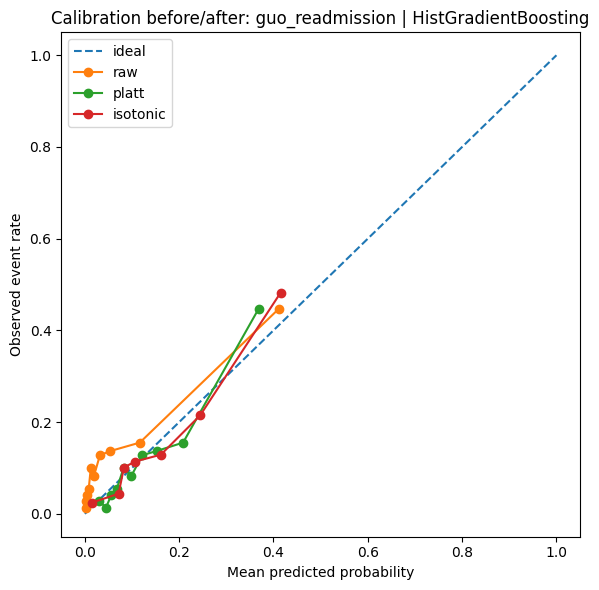

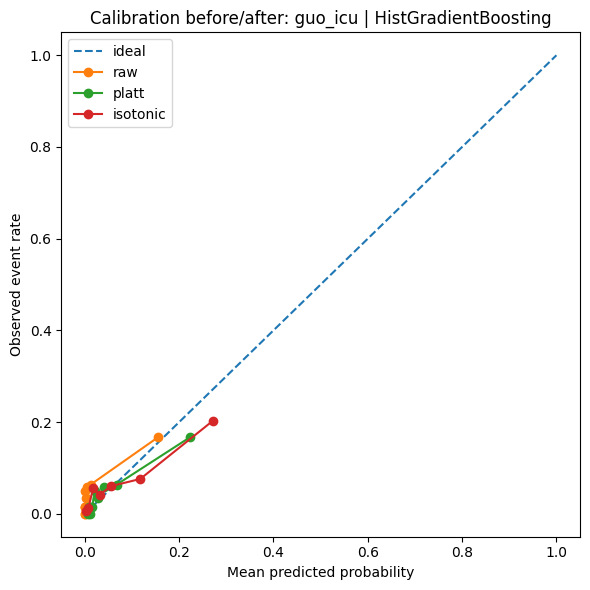

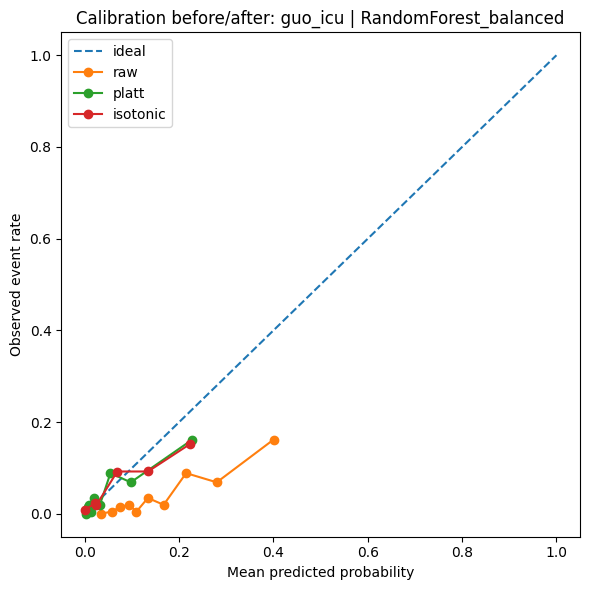

In [28]:
def calibration_table_local(y_true, y_prob, n_bins: int = 10):
    df = pd.DataFrame({
        "y_true": y_true,
        "y_prob": y_prob,
    })

    df["bin"] = pd.qcut(df["y_prob"], q=n_bins, duplicates="drop")

    out = (
        df.groupby("bin", observed=True)
        .agg(
            n=("y_true", "size"),
            mean_pred=("y_prob", "mean"),
            observed_rate=("y_true", "mean"),
        )
        .reset_index(drop=True)
    )

    return out


def plot_calibration_before_after(task_name: str, model_name: str):
    cal_preds = calibrated_predictions_by_task[task_name][model_name]

    plt.figure(figsize=(6, 6))
    plt.plot([0, 1], [0, 1], linestyle="--", label="ideal")

    for calibration_name, pred in cal_preds.items():
        cal = calibration_table_local(
            y_true=pred["y_heldout"],
            y_prob=pred["p_heldout"],
            n_bins=10,
        )

        plt.plot(
            cal["mean_pred"],
            cal["observed_rate"],
            marker="o",
            label=calibration_name,
        )

    plt.xlabel("Mean predicted probability")
    plt.ylabel("Observed event rate")
    plt.title(f"Calibration before/after: {task_name} | {model_name}")
    plt.legend()
    plt.tight_layout()
    plt.show()


for task_name, model_names in CALIBRATION_MODELS.items():
    for model_name in model_names:
        plot_calibration_before_after(task_name, model_name)

## Calibration results

После обучения классических baseline-моделей была проведена дополнительная калибровка вероятностей на `tuning` split. Калибровка нужна не для того, чтобы улучшить ранжирование пациентов, а чтобы сделать выход модели более похожим на реальную вероятность события.

Если модель хорошо откалибрована, то среди пациентов с предсказанным риском около 20% событие должно происходить примерно у 20%. Поэтому для калибровки важнее смотреть не только AUROC/AUPRC, а метрики вероятностного качества:

* **Brier score** — чем меньше, тем лучше;
* **LogLoss** — чем меньше, тем лучше;
* calibration curve — насколько точки близки к диагонали.

Были проверены три варианта:

* `raw` — исходные вероятности модели без калибровки;
* `platt` — Platt scaling, то есть логистическая калибровка на `tuning`;
* `isotonic` — isotonic regression, более гибкая монотонная калибровка.

Калибровка обучалась только на `tuning`, а оценивалась на `held_out`, чтобы не было утечки из тестовой выборки.

---

## Calibration: `guo_readmission | HistGradientBoosting`

Для задачи `guo_readmission` калибровка применялась к модели `HistGradientBoosting`, потому что она была лучшей baseline-моделью по AUPRC и Brier score до калибровки.

Результаты на `held_out`:

| Calibration | AUROC | AUPRC |     Brier |   LogLoss |        F1 | Precision | Recall |
| ----------- | ----: | ----: | --------: | --------: | --------: | --------: | -----: |
| raw         | 0.764 | 0.373 |     0.093 |     0.359 |     0.384 |     0.313 |  0.496 |
| platt       | 0.764 | 0.373 | **0.090** | **0.311** | **0.400** | **0.353** |  0.462 |
| isotonic    | 0.760 | 0.335 |     0.091 |     0.326 |     0.399 |     0.349 |  0.465 |

Основной результат: **Platt scaling улучшил калибровку вероятностей**. Brier score снизился с `0.093` до `0.090`, LogLoss снизился с `0.359` до `0.311`. Это значит, что после Platt-калибровки предсказанные вероятности стали лучше соответствовать реальной частоте readmission.

AUPRC и AUROC почти не изменились для Platt scaling, что ожидаемо: Platt scaling является монотонным преобразованием вероятностей и в основном меняет шкалу риска, а не порядок пациентов по риску. Isotonic regression в этой задаче ухудшил AUPRC с `0.373` до `0.335`, поэтому его лучше не выбирать как основной вариант.

По calibration curve видно, что после калибровки точки стали ближе к диагонали. Это особенно важно, если мы хотим интерпретировать output модели как risk score, а не просто использовать модель для ранжирования пациентов.

**Вывод по `guo_readmission`: для вероятностного risk score лучше использовать `HistGradientBoosting + Platt scaling`.**

---

## Calibration: `guo_icu | HistGradientBoosting`

Для задачи `guo_icu` была отдельно проверена калибровка `HistGradientBoosting`.

Результаты на `held_out`:

| Calibration | AUROC | AUPRC |     Brier |   LogLoss |        F1 | Precision |    Recall |
| ----------- | ----: | ----: | --------: | --------: | --------: | --------: | --------: |
| raw         | 0.787 | 0.182 |     0.039 |     0.196 | **0.247** | **0.201** | **0.318** |
| platt       | 0.787 | 0.182 | **0.038** | **0.152** |     0.200 |     0.181 |     0.224 |
| isotonic    | 0.783 | 0.145 |     0.038 |     0.156 |     0.200 |     0.181 |     0.224 |

Для `guo_icu` Platt scaling улучшил вероятностные метрики: Brier score снизился с `0.039` до `0.038`, LogLoss снизился с `0.196` до `0.152`. Это значит, что вероятности после калибровки стали более аккуратными.

При этом F1, precision и recall стали ниже, потому что после калибровки изменилась шкала вероятностей и был заново выбран threshold на `tuning`. Raw-модель агрессивнее выделяет positive class и поэтому дает более высокий recall, но ее вероятности хуже интерпретируются как реальные риски.

Isotonic regression ухудшил AUPRC с `0.182` до `0.145`, поэтому для этой задачи он выглядит менее надежным. Это ожидаемо: `guo_icu` — редкая задача с event rate около 4%, и isotonic regression может переобучаться на малом числе positive cases.

**Вывод по `guo_icu | HistGradientBoosting`: для вероятностной интерпретации лучше Platt scaling, но если цель — максимизировать screening performance по F1/recall, raw probabilities могут выглядеть лучше.**

---

## Calibration: `guo_icu | RandomForest_balanced`

Для `guo_icu` также была проверена калибровка `RandomForest_balanced`, потому что эта модель показала лучший AUPRC среди моделей для ICU.

Результаты на `held_out`:

| Calibration | AUROC | AUPRC |     Brier |   LogLoss |        F1 | Precision |    Recall |
| ----------- | ----: | ----: | --------: | --------: | --------: | --------: | --------: |
| raw         | 0.794 | 0.190 |     0.054 |     0.223 |     0.209 |     0.159 | **0.306** |
| platt       | 0.794 | 0.190 | **0.038** | **0.150** | **0.215** | **0.191** |     0.247 |
| isotonic    | 0.790 | 0.152 |     0.038 |     0.163 |     0.214 |     0.189 |     0.247 |

Здесь эффект калибровки самый заметный. У raw `RandomForest` Brier score был `0.054`, а после Platt scaling снизился до `0.038`. LogLoss также сильно улучшился: с `0.223` до `0.150`.

Это означает, что исходный Random Forest неплохо ранжировал пациентов по риску ICU transfer, но его вероятности были плохо откалиброваны и часто переоценивали риск. После Platt scaling вероятности стали намного ближе к реальной частоте события.

Isotonic regression снова ухудшил AUPRC: с `0.190` до `0.152`. Поэтому для `guo_icu` isotonic лучше не использовать как основной метод.

**Вывод по `guo_icu | RandomForest`: лучшая версия для вероятностного risk score — `RandomForest_balanced + Platt scaling`.**

---

## Calibration summary

По всем проверенным моделям Platt scaling оказался наиболее стабильным методом калибровки. Он улучшал Brier score и LogLoss, почти не ухудшая AUROC/AUPRC для readmission и ICU. Isotonic regression в наших экспериментах часто ухудшал AUPRC, особенно для `guo_icu`, поэтому его лучше не выбирать как default.

Итоговая рекомендация:

| Задача            | Модель                | Рекомендуемая версия                                         |
| ----------------- | --------------------- | ------------------------------------------------------------ |
| `guo_readmission` | HistGradientBoosting  | HistGradientBoosting + Platt scaling                         |
| `guo_icu`         | HistGradientBoosting  | HistGradientBoosting + Platt scaling, если важна вероятность |
| `guo_icu`         | RandomForest_balanced | RandomForest + Platt scaling, если выбираем модель по AUPRC  |

Важно различать две цели:

* если нужна **сортировка пациентов по риску**, смотрим AUROC/AUPRC;
* если нужна **интерпретируемая вероятность риска**, смотрим Brier, LogLoss и calibration curve.

Для медицинского risk profiling калибровка обязательна, потому что output модели должен быть похож на реальную вероятность события, а не просто на score для ранжирования.

## 10.2 Top-k risk stratification

Для нашего проекта threshold-based F1 вторичен. Практически важнее вопрос:

> Если взять top 1%, 5%, 10%, 20% пациентов по predicted risk, сколько там реальных событий и какой lift относительно среднего риска?

Это напрямую связано с risk-based routing: какую долю пациентов система направит на дополнительную проверку и сколько событий при этом будет покрыто.

In [29]:
TOPK_FRACTIONS = [0.01, 0.05, 0.10, 0.20]

TOPK_REFERENCE_MODELS = [
    {
        "task": "guo_readmission",
        "model": "HistGradientBoosting",
        "calibration": "platt",
    },
    {
        "task": "guo_icu",
        "model": "RandomForest_balanced",
        "calibration": "platt",
    },
    {
        "task": "guo_icu",
        "model": "HistGradientBoosting",
        "calibration": "platt",
    },
]


def get_heldout_metadata_for_task(task_name: str) -> pd.DataFrame:
    return (
        datasets[task_name]
        .loc[datasets[task_name]["split"] == "held_out", ["row_id", "subject_id", "label"]]
        .reset_index(drop=True)
    )


def get_prediction_vector(task_name: str, model_name: str, calibration: str = "raw"):
    if calibration == "raw":
        pred = predictions_by_task[task_name][model_name]
        return pred["y_heldout"], pred["heldout_prob"]

    pred = calibrated_predictions_by_task[task_name][model_name][calibration]
    return pred["y_heldout"], pred["p_heldout"]


def top_k_risk_table(
    task_name: str,
    model_name: str,
    calibration: str,
    topk_fractions: list[float] = TOPK_FRACTIONS,
) -> pd.DataFrame:
    y_true, y_prob = get_prediction_vector(
        task_name=task_name,
        model_name=model_name,
        calibration=calibration,
    )

    meta = get_heldout_metadata_for_task(task_name)

    assert len(meta) == len(y_true) == len(y_prob), (
        task_name,
        model_name,
        calibration,
        len(meta),
        len(y_true),
        len(y_prob),
    )

    df = meta.copy()
    df["y_true"] = y_true.astype(int)
    df["risk"] = y_prob
    df = df.sort_values("risk", ascending=False).reset_index(drop=True)

    total_examples = len(df)
    total_patients = df["subject_id"].nunique()
    total_events = int(df["y_true"].sum())
    base_event_rate = df["y_true"].mean()

    rows = []

    for frac in topk_fractions:
        n_selected = max(1, int(np.ceil(total_examples * frac)))
        top = df.head(n_selected)

        n_events = int(top["y_true"].sum())
        event_rate = top["y_true"].mean()

        rows.append({
            "task": task_name,
            "model": model_name,
            "calibration": calibration,
            "top_k_percent": int(frac * 100),
            "n_selected_examples": n_selected,
            "n_selected_patients": top["subject_id"].nunique(),
            "n_events_in_top_k": n_events,
            "total_events_heldout": total_events,
            "event_rate_in_top_k": event_rate,
            "base_event_rate": base_event_rate,
            "lift_vs_base_rate": event_rate / base_event_rate if base_event_rate > 0 else np.nan,
            "events_covered_share": n_events / total_events if total_events > 0 else np.nan,
            "examples_covered_share": n_selected / total_examples,
            "patients_covered_share": top["subject_id"].nunique() / total_patients,
            "min_risk_in_top_k": top["risk"].min(),
            "max_risk_in_top_k": top["risk"].max(),
            "mean_risk_in_top_k": top["risk"].mean(),
        })

    return pd.DataFrame(rows)


topk_tables = []

for cfg in TOPK_REFERENCE_MODELS:
    topk_tables.append(
        top_k_risk_table(
            task_name=cfg["task"],
            model_name=cfg["model"],
            calibration=cfg["calibration"],
        )
    )

topk_results_df = pd.concat(topk_tables, ignore_index=True)

display(topk_results_df)

,task,model,calibration,top_k_percent,n_selected_examples,n_selected_patients,n_events_in_top_k,total_events_heldout,event_rate_in_top_k,base_event_rate,lift_vs_base_rate,events_covered_share,examples_covered_share,patients_covered_share,min_risk_in_top_k,max_risk_in_top_k,mean_risk_in_top_k
0,guo_readmission,HistGradientBoosting,platt,1,22,12,13,260,0.590909,0.118776,4.975000,0.050000,0.010050,0.010084,0.517135,0.683288,0.579475
1,guo_readmission,HistGradientBoosting,platt,5,110,48,61,260,0.554545,0.118776,4.668846,0.234615,0.050251,0.040336,0.340970,0.683288,0.440779
2,guo_readmission,HistGradientBoosting,platt,10,219,101,98,260,0.447489,0.118776,3.767510,0.376923,0.100046,0.084874,0.258252,0.683288,0.368736
3,guo_readmission,HistGradientBoosting,platt,20,438,227,132,260,0.301370,0.118776,2.537302,0.507692,0.200091,0.190756,0.174084,0.683288,0.288522
4,guo_icu,RandomForest_balanced,platt,1,21,20,9,85,0.428571,0.041728,10.270588,0.105882,0.010309,0.017331,0.354146,0.565559,0.421571
5,guo_icu,RandomForest_balanced,platt,5,102,74,21,85,0.205882,0.041728,4.933910,0.247059,0.050074,0.064125,0.199961,0.565559,0.294590
6,guo_icu,RandomForest_balanced,platt,10,204,141,33,85,0.161765,0.041728,3.876644,0.388235,0.100147,0.122184,0.134501,0.565559,0.227860
7,guo_icu,RandomForest_balanced,platt,20,408,250,47,85,0.115196,0.041728,2.760640,0.552941,0.200295,0.216638,0.070669,0.565559,0.162584
8,guo_icu,HistGradientBoosting,platt,1,21,21,8,85,0.380952,0.041728,9.129412,0.094118,0.010309,0.018198,0.421071,0.690092,0.510566
9,guo_icu,HistGradientBoosting,platt,5,102,80,19,85,0.186275,0.041728,4.464014,0.223529,0.050074,0.069324,0.177993,0.690092,0.315017


### Результаты

Top-k evaluation показывает, что baseline модели действительно концентрируют события в высокорискованных группах пациентов. Это важно для downstream routing и resource allocation, потому что позволяет выделить небольшую группу пациентов с существенно повышенным риском.

Для `guo_readmission`, `HistGradientBoosting + Platt` достигает 44.7% readmission rate в топ 10% самых высокорискованных пациентов, что соответствует 3.77x lift относительно среднего риска в 11.9%. Топ 10% группа покрывает 37.7% всех readmission событий, а топ 20% группа покрывает 50.8%.

Для `guo_icu`, `RandomForest + Platt` достигает 42.9% ICU transfer rate в топ 1% самых высокорискованных пациентов, что соответствует 10.27x lift относительно среднего риска в 4.2%. В топ 10% группа достигает 16.2% event rate, что соответствует 3.88x lift. Топ 10% группа покрывает 38.8% всех ICU transfer событий, а топ 20% группа покрывает 55.3%.

`HistGradientBoosting + Platt` для `guo_icu` показывает аналогичное поведение: топ 1% группа достигает 38.1% ICU transfer rate (9.12x lift), топ 10% группа достигает 16.7% event rate (3.99x lift), топ 10% группа покрывает 40.0% событий, а топ 20% группа покрывает 55.3%.

В целом, top-k результаты показывают, что baseline модели полезны для risk stratification: они могут выделить относительно небольшие группы пациентов с существенно более высокой частотой событий по сравнению с популяцией в целом. Это напрямую релевантно для downstream routing и resource allocation.

## 10.3 Bootstrap uncertainty for held-out metrics

Для `guo_icu` на held-out всего 85 positive events, поэтому точечные метрики могут заметно гулять. Добавляем bootstrap 95% confidence intervals для:

- AUROC;
- AUPRC;
- top-k precision / event rate.

Bootstrap выполняется на held-out prediction examples с replacement.

In [30]:
def bootstrap_metric_ci(
    y_true,
    y_prob,
    metric_fn,
    n_bootstrap: int = 1000,
    ci: float = 0.95,
    random_state: int = RANDOM_STATE,
):
    rng = np.random.default_rng(random_state)
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob)

    n = len(y_true)
    values = []

    for _ in range(n_bootstrap):
        idx = rng.integers(0, n, size=n)
        y_b = y_true[idx]
        p_b = y_prob[idx]

        try:
            value = metric_fn(y_b, p_b)
        except Exception:
            value = np.nan

        values.append(value)

    values = np.asarray(values, dtype=float)
    values = values[~np.isnan(values)]

    alpha = 1 - ci

    return {
        "mean": float(np.mean(values)),
        "ci_low": float(np.quantile(values, alpha / 2)),
        "ci_high": float(np.quantile(values, 1 - alpha / 2)),
        "n_bootstrap_valid": int(len(values)),
    }


def auroc_metric(y, p):
    if len(np.unique(y)) < 2:
        return np.nan
    return roc_auc_score(y, p)


def auprc_metric(y, p):
    if len(np.unique(y)) < 2:
        return np.nan
    return average_precision_score(y, p)


def topk_precision_metric(k_fraction: float):
    def metric(y, p):
        y = np.asarray(y).astype(int)
        p = np.asarray(p)

        n = len(y)
        n_top = max(1, int(np.ceil(n * k_fraction)))

        order = np.argsort(-p)
        top_idx = order[:n_top]

        return float(y[top_idx].mean())

    return metric


def bootstrap_reference_model(
    task_name: str,
    model_name: str,
    calibration: str,
    topk_fractions: list[float] = TOPK_FRACTIONS,
    n_bootstrap: int = 1000,
):
    y_true, y_prob = get_prediction_vector(
        task_name=task_name,
        model_name=model_name,
        calibration=calibration,
    )

    rows = []

    for metric_name, metric_fn in [
        ("auroc", auroc_metric),
        ("auprc", auprc_metric),
    ]:
        ci_result = bootstrap_metric_ci(
            y_true=y_true,
            y_prob=y_prob,
            metric_fn=metric_fn,
            n_bootstrap=n_bootstrap,
        )

        rows.append({
            "task": task_name,
            "model": model_name,
            "calibration": calibration,
            "metric": metric_name,
            **ci_result,
        })

    for frac in topk_fractions:
        ci_result = bootstrap_metric_ci(
            y_true=y_true,
            y_prob=y_prob,
            metric_fn=topk_precision_metric(frac),
            n_bootstrap=n_bootstrap,
        )

        rows.append({
            "task": task_name,
            "model": model_name,
            "calibration": calibration,
            "metric": f"top_{int(frac * 100)}pct_precision",
            **ci_result,
        })

    return pd.DataFrame(rows)


bootstrap_ci_tables = []

for cfg in TOPK_REFERENCE_MODELS:
    print("\n" + "=" * 100)
    print("Bootstrap:", cfg)
    boot_df = bootstrap_reference_model(
        task_name=cfg["task"],
        model_name=cfg["model"],
        calibration=cfg["calibration"],
        n_bootstrap=1000,
    )
    bootstrap_ci_tables.append(boot_df)
    display(boot_df)

bootstrap_ci_df = pd.concat(bootstrap_ci_tables, ignore_index=True)
display(bootstrap_ci_df)


Bootstrap: {'task': 'guo_readmission', 'model': 'HistGradientBoosting', 'calibration': 'platt'}


,task,model,calibration,metric,mean,ci_low,ci_high,n_bootstrap_valid
0,guo_readmission,HistGradientBoosting,platt,auroc,0.764408,0.733452,0.796666,1000
1,guo_readmission,HistGradientBoosting,platt,auprc,0.375483,0.313803,0.438403,1000
2,guo_readmission,HistGradientBoosting,platt,top_1pct_precision,0.589727,0.363636,0.772727,1000
3,guo_readmission,HistGradientBoosting,platt,top_5pct_precision,0.541918,0.445455,0.636364,1000
4,guo_readmission,HistGradientBoosting,platt,top_10pct_precision,0.446484,0.378995,0.515982,1000
5,guo_readmission,HistGradientBoosting,platt,top_20pct_precision,0.304779,0.262557,0.349315,1000



Bootstrap: {'task': 'guo_icu', 'model': 'RandomForest_balanced', 'calibration': 'platt'}


,task,model,calibration,metric,mean,ci_low,ci_high,n_bootstrap_valid
0,guo_icu,RandomForest_balanced,platt,auroc,0.794385,0.743230,0.839501,1000
1,guo_icu,RandomForest_balanced,platt,auprc,0.198161,0.129531,0.276394,1000
2,guo_icu,RandomForest_balanced,platt,top_1pct_precision,0.399905,0.190476,0.619048,1000
3,guo_icu,RandomForest_balanced,platt,top_5pct_precision,0.199902,0.127451,0.284314,1000
4,guo_icu,RandomForest_balanced,platt,top_10pct_precision,0.155054,0.107843,0.205882,1000
5,guo_icu,RandomForest_balanced,platt,top_20pct_precision,0.117804,0.088174,0.151961,1000



Bootstrap: {'task': 'guo_icu', 'model': 'HistGradientBoosting', 'calibration': 'platt'}


,task,model,calibration,metric,mean,ci_low,ci_high,n_bootstrap_valid
0,guo_icu,HistGradientBoosting,platt,auroc,0.787287,0.740376,0.832089,1000
1,guo_icu,HistGradientBoosting,platt,auprc,0.190216,0.123069,0.271855,1000
2,guo_icu,HistGradientBoosting,platt,top_1pct_precision,0.383571,0.190476,0.572619,1000
3,guo_icu,HistGradientBoosting,platt,top_5pct_precision,0.194598,0.117647,0.284314,1000
4,guo_icu,HistGradientBoosting,platt,top_10pct_precision,0.166314,0.117647,0.220588,1000
5,guo_icu,HistGradientBoosting,platt,top_20pct_precision,0.116326,0.083333,0.149510,1000


,task,model,calibration,metric,mean,ci_low,ci_high,n_bootstrap_valid
0,guo_readmission,HistGradientBoosting,platt,auroc,0.764408,0.733452,0.796666,1000
1,guo_readmission,HistGradientBoosting,platt,auprc,0.375483,0.313803,0.438403,1000
2,guo_readmission,HistGradientBoosting,platt,top_1pct_precision,0.589727,0.363636,0.772727,1000
3,guo_readmission,HistGradientBoosting,platt,top_5pct_precision,0.541918,0.445455,0.636364,1000
4,guo_readmission,HistGradientBoosting,platt,top_10pct_precision,0.446484,0.378995,0.515982,1000
5,guo_readmission,HistGradientBoosting,platt,top_20pct_precision,0.304779,0.262557,0.349315,1000
6,guo_icu,RandomForest_balanced,platt,auroc,0.794385,0.743230,0.839501,1000
7,guo_icu,RandomForest_balanced,platt,auprc,0.198161,0.129531,0.276394,1000
8,guo_icu,RandomForest_balanced,platt,top_1pct_precision,0.399905,0.190476,0.619048,1000
9,guo_icu,RandomForest_balanced,platt,top_5pct_precision,0.199902,0.127451,0.284314,1000


### Общий вывод по bootstrap uncertainty / variance метрик

Bootstrap-анализ показывает, что качество classical baselines в целом устойчиво выше случайного baseline, но степень uncertainty различается между задачами и метриками.

Для `guo_readmission` результаты выглядят наиболее стабильными. Модель `HistGradientBoosting + Platt calibration` показывает AUROC около `0.764` с 95% CI `[0.733, 0.797]` и AUPRC около `0.375` с 95% CI `[0.314, 0.438]`. Интервалы не слишком широкие, поэтому можно считать, что readmission baseline достаточно устойчив на held-out split. Top-k precision также стабильно выше среднего event rate: даже нижняя граница confidence interval для top 10% precision равна `0.379`, что существенно выше base event rate `0.119`. Это означает, что модель надежно концентрирует readmission events в верхней группе риска.

Для `guo_icu` uncertainty заметно выше. Это ожидаемо, потому что ICU transfer — более редкое событие, и на held-out split всего 85 positive cases. У `RandomForest + Platt` AUPRC равен примерно `0.198`, но 95% CI достаточно широкий: `[0.130, 0.276]`. У `HistGradientBoosting + Platt` AUPRC примерно `0.190`, 95% CI `[0.123, 0.272]`. Эти интервалы сильно перекрываются, поэтому нельзя уверенно утверждать, что одна из двух моделей лучше другой по AUPRC. Разница между ними находится в пределах bootstrap variance.

Top-k метрики для ICU тоже имеют более широкие интервалы, особенно для top 1%. Это связано с тем, что top 1% содержит очень мало examples, поэтому precision сильно зависит от нескольких отдельных пациентов. Более надежными для интерпретации являются top 5%, top 10% и top 20%. Даже для них confidence intervals остаются выше base event rate `0.042`, что говорит о стабильной способности моделей выделять группу повышенного риска.

В целом bootstrap показывает, что classical baselines дают устойчивое risk stratification поведение: верхние risk groups имеют event rate значительно выше среднего. Однако для ICU любые небольшие различия между моделями нужно интерпретировать осторожно из-за высокой variance метрик. Поэтому для дальнейшего сравнения с sequence-based или missing-aware моделями важно смотреть не только точечные AUROC/AUPRC, но и confidence intervals. Улучшение новой модели будет убедительным только если оно выходит за пределы bootstrap uncertainty текущих baselines.

## 11. Feature importance

Интерпретация:
- для RandomForest / CatBoost смотрим feature importances;
- для HistGradientBoosting в sklearn нет прямого `feature_importances_`, поэтому здесь используем permutation importance на held_out split;

In [31]:
from sklearn.inspection import permutation_importance


FEATURE_IMPORTANCE_MODELS = {
    "guo_readmission": [
        "HistGradientBoosting",
    ],
    "guo_icu": [
        "HistGradientBoosting",
        "RandomForest_balanced",
    ],
}


def make_stratified_eval_sample(df: pd.DataFrame, max_rows: int = 1500):
    """
    Делаем небольшой eval sample для permutation importance,
    чтобы не считать слишком долго.

    Сохраняем все positives, если их не слишком много,
    и досэмплируем negatives.
    """
    if len(df) <= max_rows:
        return df.copy()

    pos = df[df["label"] == 1]
    neg = df[df["label"] == 0]

    n_pos = len(pos)
    n_neg_needed = max_rows - n_pos

    if n_neg_needed <= 0:
        return pos.sample(n=max_rows, random_state=RANDOM_STATE)

    neg_sample = neg.sample(
        n=min(n_neg_needed, len(neg)),
        random_state=RANDOM_STATE,
    )

    return (
        pd.concat([pos, neg_sample], axis=0)
        .sample(frac=1.0, random_state=RANDOM_STATE)
        .reset_index(drop=True)
    )


def get_builtin_feature_importance(model, feature_cols: list[str]):
    """
    Built-in importance для RandomForest / tree ensembles.
    Для HistGradientBoosting обычно не подходит, потому что там нет feature_importances_.
    """
    if not hasattr(model, "feature_importances_"):
        return None

    importance = model.feature_importances_

    out = (
        pd.DataFrame({
            "feature": feature_cols,
            "importance": importance,
        })
        .sort_values("importance", ascending=False)
        .reset_index(drop=True)
    )

    return out


def get_permutation_feature_importance(
    model,
    df: pd.DataFrame,
    feature_cols: list[str],
    max_rows: int = 1500,
    n_repeats: int = 5,
    scoring: str = "average_precision",
):
    """
    Permutation importance на held_out.

    scoring='average_precision' означает, что важность признака измеряется
    через падение AUPRC после перемешивания этого признака.
    """
    heldout_df = df[df["split"] == "held_out"].copy()
    eval_df = make_stratified_eval_sample(heldout_df, max_rows=max_rows)

    X_eval = eval_df[feature_cols].values
    y_eval = eval_df["label"].astype(int).values

    result = permutation_importance(
        estimator=model,
        X=X_eval,
        y=y_eval,
        scoring=scoring,
        n_repeats=n_repeats,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )

    out = (
        pd.DataFrame({
            "feature": feature_cols,
            "importance_mean": result.importances_mean,
            "importance_std": result.importances_std,
        })
        .sort_values("importance_mean", ascending=False)
        .reset_index(drop=True)
    )

    return out


feature_importance_tables = {}

for task_name, model_names in FEATURE_IMPORTANCE_MODELS.items():
    feature_importance_tables[task_name] = {}

    for model_name in model_names:
        print("\n" + "=" * 100)
        print(f"Feature importance: {task_name} | {model_name}")

        model = fitted_models_by_task[task_name][model_name]
        df = datasets[task_name]
        feature_cols = feature_cols_by_task[task_name]

        if model_name == "RandomForest_balanced":
            # Для RF сначала берем быстрый built-in importance.
            importance_df = get_builtin_feature_importance(
                model=model,
                feature_cols=feature_cols,
            )
            importance_type = "builtin_gini_importance"
        else:
            # Для HistGradientBoosting используем permutation importance.
            importance_df = get_permutation_feature_importance(
                model=model,
                df=df,
                feature_cols=feature_cols,
                max_rows=1500,
                n_repeats=5,
                scoring="average_precision",
            )
            importance_type = "permutation_importance_auprc"

        importance_df["task"] = task_name
        importance_df["model"] = model_name
        importance_df["importance_type"] = importance_type

        feature_importance_tables[task_name][model_name] = importance_df

        display(importance_df.head(30))


Feature importance: guo_readmission | HistGradientBoosting


,feature,importance_mean,importance_std,task,model,importance_type
0,code_count__RxNorm__197900,0.062929,0.012182,guo_readmission,HistGradientBoosting,permutation_importance_auprc
1,code_count__RxNorm__197582,0.026149,0.001354,guo_readmission,HistGradientBoosting,permutation_importance_auprc
2,n_numeric_events_last_30d,0.019144,0.003423,guo_readmission,HistGradientBoosting,permutation_importance_auprc
3,num_last__LOINC__3151_8,0.018042,0.008269,guo_readmission,HistGradientBoosting,permutation_importance_auprc
4,family_count__Condition_Type,0.009617,0.002459,guo_readmission,HistGradientBoosting,permutation_importance_auprc
5,code_count__RxNorm__1868486,0.009227,0.004909,guo_readmission,HistGradientBoosting,permutation_importance_auprc
6,code_count__RxNorm__238100,0.006596,0.003202,guo_readmission,HistGradientBoosting,permutation_importance_auprc
7,num_mean__LOINC__2951_2,0.006587,0.002084,guo_readmission,HistGradientBoosting,permutation_importance_auprc
8,num_max__LOINC__788_0,0.006472,0.003822,guo_readmission,HistGradientBoosting,permutation_importance_auprc
9,n_visit_events_last_90d,0.006359,0.001065,guo_readmission,HistGradientBoosting,permutation_importance_auprc



Feature importance: guo_icu | HistGradientBoosting


,feature,importance_mean,importance_std,task,model,importance_type
0,code_count__LOINC__84061_1,0.036639,0.005762,guo_icu,HistGradientBoosting,permutation_importance_auprc
1,code_count__SNOMED__410188000,0.027943,0.011125,guo_icu,HistGradientBoosting,permutation_importance_auprc
2,num_min__LOINC__788_0,0.018058,0.004015,guo_icu,HistGradientBoosting,permutation_importance_auprc
3,family_count__CARE_SITE,0.017735,0.007938,guo_icu,HistGradientBoosting,permutation_importance_auprc
4,code_count__CPT4__71020,0.017259,0.007450,guo_icu,HistGradientBoosting,permutation_importance_auprc
5,n_visit_events_last_30d,0.016098,0.004953,guo_icu,HistGradientBoosting,permutation_importance_auprc
6,code_count__LOINC__49229_8,0.016010,0.005295,guo_icu,HistGradientBoosting,permutation_importance_auprc
7,num_last__LOINC__777_3,0.015222,0.004191,guo_icu,HistGradientBoosting,permutation_importance_auprc
8,n_rxnorm_events_last_30d,0.014547,0.007167,guo_icu,HistGradientBoosting,permutation_importance_auprc
9,num_mean__LOINC__8867_4,0.013410,0.006502,guo_icu,HistGradientBoosting,permutation_importance_auprc



Feature importance: guo_icu | RandomForest_balanced


,feature,importance,task,model,importance_type
0,family_count__CARE_SITE,0.012397,guo_icu,RandomForest_balanced,builtin_gini_importance
1,code_count__CPT4__86850,0.011304,guo_icu,RandomForest_balanced,builtin_gini_importance
2,code_count__CPT4__71020,0.010678,guo_icu,RandomForest_balanced,builtin_gini_importance
3,n_cpt4_events_last_30d,0.009985,guo_icu,RandomForest_balanced,builtin_gini_importance
4,num_min__LOINC__8310_5,0.009486,guo_icu,RandomForest_balanced,builtin_gini_importance
5,num_mean__LOINC__38214_3,0.009264,guo_icu,RandomForest_balanced,builtin_gini_importance
6,code_count__CPT4__86901,0.008706,guo_icu,RandomForest_balanced,builtin_gini_importance
7,code_count__CPT4__86900,0.007940,guo_icu,RandomForest_balanced,builtin_gini_importance
8,n_rxnorm_events_last_30d,0.007461,guo_icu,RandomForest_balanced,builtin_gini_importance
9,num_min__LOINC__788_0,0.007379,guo_icu,RandomForest_balanced,builtin_gini_importance


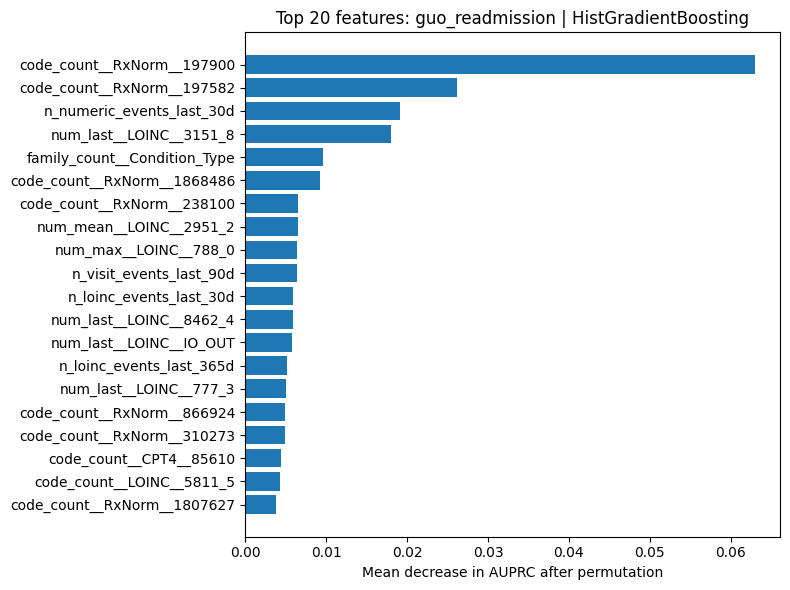

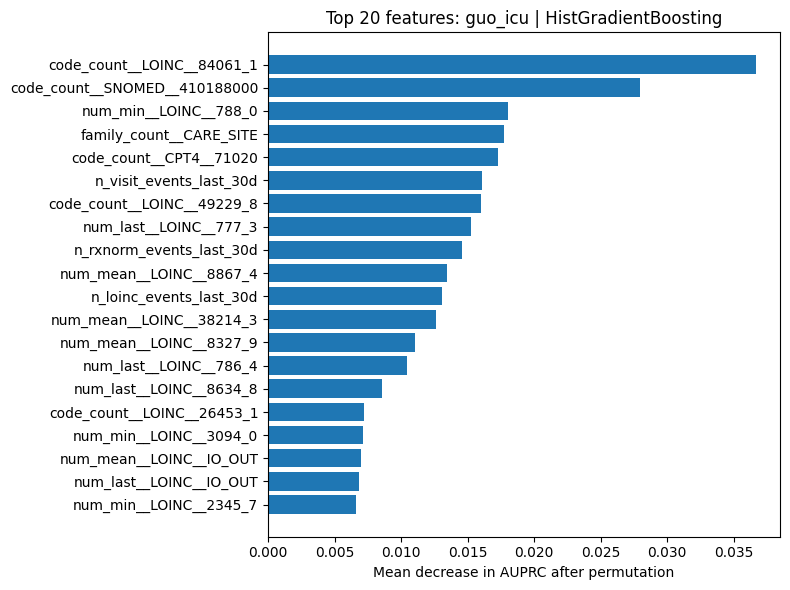

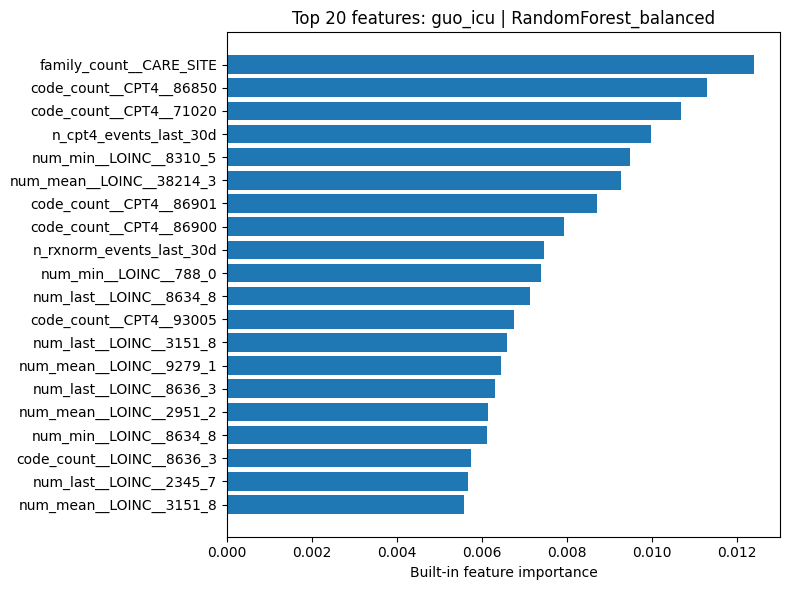

In [32]:
def plot_top_feature_importance(
    importance_df: pd.DataFrame,
    task_name: str,
    model_name: str,
    top_n: int = 20,
):
    plot_df = importance_df.head(top_n).copy()

    if "importance_mean" in plot_df.columns:
        value_col = "importance_mean"
        xlabel = "Mean decrease in AUPRC after permutation"
    else:
        value_col = "importance"
        xlabel = "Built-in feature importance"

    plot_df = plot_df.sort_values(value_col, ascending=True)

    plt.figure(figsize=(8, max(5, top_n * 0.3)))
    plt.barh(plot_df["feature"], plot_df[value_col])
    plt.xlabel(xlabel)
    plt.title(f"Top {top_n} features: {task_name} | {model_name}")
    plt.tight_layout()
    plt.show()


for task_name, model_tables in feature_importance_tables.items():
    for model_name, importance_df in model_tables.items():
        plot_top_feature_importance(
            importance_df=importance_df,
            task_name=task_name,
            model_name=model_name,
            top_n=20,
        )

In [33]:
FEATURE_IMPORTANCE_DIR = Path("ehrshot_feature_importance")
FEATURE_IMPORTANCE_DIR.mkdir(exist_ok=True)

all_importance_dfs = []

for task_name, model_tables in feature_importance_tables.items():
    for model_name, importance_df in model_tables.items():
        out_path = FEATURE_IMPORTANCE_DIR / f"{task_name}__{model_name}__feature_importance.csv"
        importance_df.to_csv(out_path, index=False)
        print("Saved:", out_path)

        all_importance_dfs.append(importance_df)

all_feature_importance_df = pd.concat(all_importance_dfs, ignore_index=True)

all_importance_path = FEATURE_IMPORTANCE_DIR / "all_selected_feature_importances.csv"
all_feature_importance_df.to_csv(all_importance_path, index=False)

print("Saved:", all_importance_path)

Saved: ehrshot_feature_importance/guo_readmission__HistGradientBoosting__feature_importance.csv
Saved: ehrshot_feature_importance/guo_icu__HistGradientBoosting__feature_importance.csv
Saved: ehrshot_feature_importance/guo_icu__RandomForest_balanced__feature_importance.csv
Saved: ehrshot_feature_importance/all_selected_feature_importances.csv


## Feature importance: `guo_readmission | HistGradientBoosting`

Для `HistGradientBoosting` feature importance считалась через permutation importance на `held_out`. Важность признака измерялась как падение AUPRC после случайного перемешивания этого признака. Это более подходящий метод для данной задачи, потому что `HistGradientBoostingClassifier` в sklearn не имеет обычного `feature_importances_`.

Топ важных признаков для `guo_readmission`:

| Feature group           | Примеры признаков                                                                                        | Интерпретация                                                                                                                                                   |
| ----------------------- | -------------------------------------------------------------------------------------------------------- | --------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| Medication history      | `code_count__RxNorm__197900`, `code_count__RxNorm__197582`, `code_count__RxNorm__1868486`                | Частота лекарственных событий до выписки. Medication history может отражать тяжесть состояния, коморбидности и интенсивность лечения.                           |
| Recent numeric activity | `n_numeric_events_last_30d`, `n_loinc_events_last_30d`, `n_loinc_events_last_365d`                       | Количество лабораторных/измеряемых событий перед prediction time. Частые измерения могут быть маркером более тяжелого состояния или более активного наблюдения. |
| Lab / vital values      | `num_last__LOINC__3151_8`, `num_mean__LOINC__2951_2`, `num_max__LOINC__788_0`, `num_last__LOINC__8462_4` | Последние, средние и экстремальные значения лабораторных/vital показателей.                                                                                     |
| Visit history           | `n_visit_events_last_90d`                                                                                | Количество визитов в недавнем прошлом. Может отражать healthcare utilization и риск повторного обращения.                                                       |
| Procedures / conditions | `code_count__CPT4__85610`, `code_count__SNOMED__410188000`                                               | Процедурные и клинические события, которые могут быть связаны с тяжестью состояния.                                                                             |

Главный вывод: readmission baseline опирается не на один тип признаков, а на комбинацию medication history, recent lab activity, numeric values, visits and procedures. Это клинически правдоподобно: риск повторной госпитализации обычно связан не только с диагнозом, но и с недавней интенсивностью наблюдения, лекарствами, процедурами и лабораторными показателями.

Также видно, что признаки последних 30/90/365 дней важны. Это подтверждает, что recent history действительно полезна для readmission prediction.

Важно: коды `RxNorm`, `LOINC`, `SNOMED` и `CPT4` нужно дополнительно сопоставить со словарями, если мы хотим писать клиническую интерпретацию конкретных кодов. Сейчас по названиям колонок мы можем надежно интерпретировать семейство признака, но не всегда точное медицинское значение каждого кода.

---

## Feature importance: `guo_icu | HistGradientBoosting`

Для `guo_icu | HistGradientBoosting` также использовалась permutation importance по AUPRC.

Топ важных признаков:

| Feature group                   | Примеры признаков                                                                                                                        | Интерпретация                                                                                                                                                |
| ------------------------------- | ---------------------------------------------------------------------------------------------------------------------------------------- | ------------------------------------------------------------------------------------------------------------------------------------------------------------ |
| LOINC events and numeric values | `code_count__LOINC__84061_1`, `code_count__LOINC__49229_8`, `num_min__LOINC__788_0`, `num_last__LOINC__777_3`, `num_mean__LOINC__8867_4` | Лабораторные/vital признаки играют заметную роль для предсказания ICU transfer. Это ожидаемо, потому что риск ICU часто связан с физиологическим ухудшением. |
| Clinical condition history      | `code_count__SNOMED__410188000`                                                                                                          | Клинические состояния/признаки из истории пациента участвуют в прогнозе ICU transfer.                                                                        |
| Care site / encounter context   | `family_count__CARE_SITE`, `n_visit_events_last_30d`                                                                                     | Контекст оказания помощи и недавние визиты важны для оценки риска.                                                                                           |
| Procedures                      | `code_count__CPT4__71020`                                                                                                                | Процедурные события могут отражать тяжесть состояния или диагностическую активность.                                                                         |
| Recent medication activity      | `n_rxnorm_events_last_30d`                                                                                                               | Недавние medication events могут быть связаны с остротой состояния пациента.                                                                                 |

Главный вывод: для ICU transfer модель использует признаки, связанные с недавней клинической активностью, лабораторными/vital значениями, процедурами и care-site контекстом. Это выглядит клинически осмысленно, потому что ICU transfer обычно связан с текущей тяжестью состояния, а не только с долгой историей пациента.

Особенно важно, что среди top features есть recent-window признаки, например `n_visit_events_last_30d`, `n_rxnorm_events_last_30d`, `n_loinc_events_last_30d`. Это показывает, что короткая история перед admission/index time полезна для предсказания ICU transfer.

---

## Feature importance: `guo_icu | RandomForest_balanced`

Для `RandomForest_balanced` использовалась встроенная tree-based importance. Ее нужно интерпретировать осторожнее, чем permutation importance, потому что impurity-based importance может быть смещена в сторону признаков с большим числом возможных значений или высокой вариативностью.

Топ важных признаков:

| Feature group               | Примеры признаков                                                                                                                    | Интерпретация                                                                                                |
| --------------------------- | ------------------------------------------------------------------------------------------------------------------------------------ | ------------------------------------------------------------------------------------------------------------ |
| Care site context           | `family_count__CARE_SITE`                                                                                                            | Один из самых важных признаков. Вероятно, контекст места оказания помощи связан с вероятностью ICU transfer. |
| Procedures                  | `code_count__CPT4__86850`, `code_count__CPT4__71020`, `code_count__CPT4__86901`, `code_count__CPT4__86900`, `n_cpt4_events_last_30d` | Процедурные события и их недавняя частота сильно влияют на прогноз ICU transfer.                             |
| Numeric lab/vital features  | `num_min__LOINC__8310_5`, `num_mean__LOINC__38214_3`, `num_min__LOINC__788_0`, `num_last__LOINC__8634_8`                             | Лабораторные и vital показатели важны для оценки риска ухудшения состояния.                                  |
| Recent medication activity  | `n_rxnorm_events_last_30d`                                                                                                           | Недавние medication events могут отражать интенсивность лечения или клиническую нестабильность.              |
| ECG / procedure-like events | `code_count__CPT4__93005`, `code_count__CPT4__93010`                                                                                 | Некоторые процедурные коды могут быть маркерами более интенсивного обследования пациента.                    |

В RandomForest важнее оказались care site и procedure-related признаки, тогда как в HistGradientBoosting сильнее видны LOINC/numeric признаки. Это нормальная разница между моделями: разные алгоритмы могут использовать разные группы признаков для достижения похожего качества.

Общий вывод по ICU feature importance: обе модели считают важными признаки, связанные с клинической интенсивностью перед index time — процедуры, лабораторные/vital показатели, care site и недавние события. Это подтверждает, что модели используют правдоподобные EHR-сигналы, а не случайные признаки.

## 12. Save results

Сохраняем таблицу сравнения моделей.  
После запуска можно вставить ее в Confluence.

In [34]:
RESULTS_DIR = Path("ehrshot_baseline_results")
RESULTS_DIR.mkdir(exist_ok=True)

results_path = RESULTS_DIR / "classical_baseline_results.csv"
comparison_path = RESULTS_DIR / "classical_baseline_comparison.csv"
calibration_path = RESULTS_DIR / "classical_baseline_calibration_results.csv"

results_df.to_csv(results_path, index=False)
comparison_df.to_csv(comparison_path, index=False)
calibration_results_df.to_csv(calibration_path, index=False)

print("Saved:", results_path)
print("Saved:", comparison_path)
print("Saved:", calibration_path)

Saved: ehrshot_baseline_results/classical_baseline_results.csv
Saved: ehrshot_baseline_results/classical_baseline_comparison.csv
Saved: ehrshot_baseline_results/classical_baseline_calibration_results.csv


## 13. Final summary

После построения classical baselines, калибровки, top-k анализа, ablation-проверок и bootstrap uncertainty analysis можно сделать несколько основных выводов.

Во-первых, классические tabular baseline-модели действительно находят предсказательный сигнал в EHRSHOT-MEDS для обеих задач: `guo_readmission` и `guo_icu`. Все основные tree/boosting модели заметно превосходят Dummy baseline по AUROC и AUPRC. Это означает, что агрегированная история пациента до `prediction_time` содержит полезную информацию для оценки риска readmission и ICU transfer.

Для `guo_readmission` лучшей основной моделью стала `HistGradientBoosting + Platt scaling`. На held-out split она показала:

* AUROC = 0.764;
* AUPRC = 0.373;
* Brier score = 0.090;
* LogLoss = 0.311;
* F1 = 0.400;
* Precision = 0.353;
* Recall = 0.462.

Для `guo_icu` рассматривались две близкие baseline-модели:

* `RandomForest_balanced + Platt scaling`;
* `HistGradientBoosting + Platt scaling`.

`RandomForest_balanced + Platt` показал лучший ranking baseline по AUPRC:

* AUROC = 0.794;
* AUPRC = 0.190;
* Brier score = 0.038;
* LogLoss = 0.150.

`HistGradientBoosting + Platt` дал очень близкое качество:

* AUROC = 0.787;
* AUPRC = 0.182;
* Brier score = 0.038;
* LogLoss = 0.152.

Поэтому для `guo_icu` нельзя уверенно считать одну из этих моделей явно лучше другой: RandomForest немного сильнее по AUPRC, но HistGradientBoosting остается близкой альтернативной baseline-моделью с сопоставимой калибровкой и top-k поведением. Однако по bootstrap confidence intervals нельзя уверенно утверждать, что она статистически лучше или стабильнее RandomForest.

Во-вторых, калибровка вероятностей оказалась важной частью baseline pipeline. Raw-модели могут хорошо ранжировать пациентов, но их вероятности не всегда соответствуют реальной частоте события. Это особенно заметно для balanced-моделей и для более редкой задачи `guo_icu`. Platt scaling улучшил Brier score и LogLoss почти во всех выбранных моделях, при этом почти не меняя AUROC/AUPRC. Isotonic regression оказался менее стабильным и местами ухудшал AUPRC, особенно для ICU, поэтому в качестве основного метода калибровки был выбран Platt scaling.

В-третьих, top-k анализ показал, что модели полезны именно для risk stratification. Для проекта это важнее, чем одиночный F1-threshold, потому что практический сценарий связан с маршрутизацией и выделением небольшой группы пациентов с повышенным риском.

Для `guo_readmission` модель `HistGradientBoosting + Platt` хорошо концентрирует readmission events в верхних risk groups:

* top 1%: event rate = 59.1%, lift = 4.98x;
* top 5%: event rate = 55.5%, lift = 4.67x;
* top 10%: event rate = 44.7%, lift = 3.77x;
* top 20%: event rate = 30.1%, lift = 2.54x.

При этом top 10% examples покрывают 37.7% всех readmission events, а top 20% — 50.8%.

Для `guo_icu` средний event rate на held-out составляет около 4.2%, поэтому задача существенно более дисбалансная. Однако модели все равно хорошо выделяют high-risk группу. Для `RandomForest_balanced + Platt`:

* top 1%: event rate = 42.9%, lift = 10.27x;
* top 5%: event rate = 20.6%, lift = 4.93x;
* top 10%: event rate = 16.2%, lift = 3.88x;
* top 20%: event rate = 11.5%, lift = 2.76x.

Top 10% examples покрывают 38.8% всех ICU transfers, а top 20% — 55.3%. `HistGradientBoosting + Platt` показывает очень похожее поведение: top 10% покрывает 40.0% ICU transfers, top 20% — 55.3%.

В-четвертых, были проведены ablation-проверки на возможные служебные/proxy-признаки. Для этого сравнивались четыре набора признаков:

* `all_features`;
* `no_service_proxy`, то есть без `CARE_SITE`, `CMS Place of Service`, `Medicare Specialty`;
* `no_cpt4`;
* `clinical_only`, то есть только признаки, явно связанные с `LOINC`, `SNOMED`, `RxNorm`, `Visit`.

Ablation не показал, что качество моделей критически держится на служебных/proxy-признаках. Для `guo_readmission` удаление service/proxy признаков почти не ухудшило результат: у `HistGradientBoosting` AUPRC снизился с 0.373 до 0.364. Clinical-only версия также осталась существенно выше Dummy baseline.

Для `guo_icu` результаты были более вариативными, что ожидаемо из-за малого числа positive cases. Однако даже clinical-only модели оставались заметно выше Dummy baseline. Дополнительно для ICU был проведен paired bootstrap для различий AUPRC между `all_features` и ablated variants. Во всех сравнениях 95% confidence intervals для разницы AUPRC включали 0. Это значит, что наблюдаемые различия между full-feature и ablated моделями не являются статистически устойчивыми. Следовательно, нет evidence, что ICU baseline критически зависит от service/proxy признаков или явной proxy-leakage.

В-пятых, была проверена чувствительность к границе времени при построении признаков. Основной pipeline использует события с условием:

`event.time <= prediction_time`

Дополнительно был проверен более строгий вариант:

`event.time < prediction_time`

Эта проверка особенно важна для `guo_icu`, потому что события ровно в `prediction_time` потенциально могут отражать состояние пациента уже слишком близко к outcome. Результаты не показали систематического падения качества при строгом cutoff. Для ICU AUPRC у CatBoost и RandomForest даже немного вырос, а у HistGradientBoosting снизился только незначительно. Это говорит о том, что качество ICU baseline не держится на событиях, происходящих ровно в `prediction_time`.

Дополнительно была предпринята попытка восстановить точное время ICU transfer из MEDS event timeline. Однако descriptions для relevant local/service codes оказались пустыми, поэтому надежно определить конкретный ICU transfer event только по MEDS metadata нельзя. В текущем анализе это фиксируется как ограничение. Однако, по официальному описанию EHRSHOT, `prediction_time` для ICU transfer задан как 23:59 в день admission, и ICU transfers, произошедшие в тот же день admission, игнорируются. Поэтому случаи, где ICU transfer уже произошел в день admission до `prediction_time`, не должны попадать в датасет для данной задачи.

В-шестых, bootstrap uncertainty analysis показал, что `guo_readmission` baseline более устойчив, чем `guo_icu`. Для `guo_readmission` модель `HistGradientBoosting + Platt` имеет:

* AUROC = 0.764, 95% CI [0.733, 0.797];
* AUPRC = 0.375, 95% CI [0.314, 0.438].

Top-k precision для readmission также устойчиво выше среднего event rate. Например, top 10% precision = 0.446, 95% CI [0.379, 0.516], что существенно выше base event rate 0.119.

Для `guo_icu` uncertainty выше из-за малого числа positive events на held-out. У `RandomForest_balanced + Platt`:

* AUROC = 0.794, 95% CI [0.743, 0.840];
* AUPRC = 0.198, 95% CI [0.130, 0.276].

У `HistGradientBoosting + Platt`:

* AUROC = 0.787, 95% CI [0.740, 0.832];
* AUPRC = 0.190, 95% CI [0.123, 0.272].

Confidence intervals у двух ICU моделей сильно перекрываются, поэтому нельзя делать сильный вывод, что одна модель статистически надежно лучше другой. Однако обе модели стабильно выделяют high-risk группы: top-k precision остается выше среднего ICU event rate даже на нижних границах confidence intervals для top 5%, top 10% и top 20%.

Feature importance анализ показал, что модели используют клинически правдоподобные группы признаков: laboratory/numeric events, medication history, procedure counts, recent-window activity, visit history и общие признаки интенсивности медицинского наблюдения. Для `HistGradientBoosting` использовалась permutation importance по AUPRC, для RandomForest — встроенная tree-based importance. Эти результаты не являются финальной клинической объяснимостью, но служат sanity check: модели не выглядят основанными на одном подозрительном признаке.

Итоговый выбор reference baselines для дальнейшего сравнения:

* для `guo_readmission`: `HistGradientBoosting + Platt scaling`;
* для `guo_icu`: `RandomForest_balanced + Platt scaling` как лучший ranking baseline;

Для `guo_icu` основной ranking baseline — `RandomForest_balanced + Platt scaling`, так как он имеет лучший point estimate по AUPRC. При этом `HistGradientBoosting + Platt scaling` показывает очень близкое качество, сопоставимый Brier/LogLoss и похожие top-k результаты. Bootstrap confidence intervals для этих моделей сильно перекрываются, поэтому различие между ними не следует интерпретировать как статистически устойчивое.

Для будущих sequence-based, missing-aware или compression-aware моделей сравнение нужно проводить не только по точечным AUROC/AUPRC, но и по:

* bootstrap confidence intervals;
* top-k event rate / precision;
* lift относительно base event rate;
* events covered share;
* Brier score и LogLoss для вероятностной калибровки.

Новая модель будет убедительно лучше classical baseline только если она улучшает не только point estimates, но и показывает устойчивое улучшение за пределами bootstrap uncertainty, особенно для редкой задачи `guo_icu`.

In [35]:
# Export held-out tabular predictions for subgroup analysis

from pathlib import Path
import pandas as pd

RESULTS_DIR = Path("ehrshot_baseline_results")
RESULTS_DIR.mkdir(exist_ok=True)

TABULAR_PREDICTIONS_PATH = RESULTS_DIR / "classical_baseline_heldout_predictions.csv"

TABULAR_REFERENCE_MODELS = [
    {
        "task": "guo_readmission",
        "model": "HistGradientBoosting",
        "calibration": "platt",
    },
    {
        "task": "guo_icu",
        "model": "RandomForest_balanced",
        "calibration": "platt",
    },
    {
        "task": "guo_icu",
        "model": "HistGradientBoosting",
        "calibration": "platt",
    },
]

tabular_prediction_parts = []

for cfg in TABULAR_REFERENCE_MODELS:
    task_name = cfg["task"]
    model_name = cfg["model"]
    calibration = cfg["calibration"]

    meta = (
        datasets[task_name]
        .loc[datasets[task_name]["split"] == "held_out", ["row_id", "subject_id", "label"]]
        .reset_index(drop=True)
    )

    pred = calibrated_predictions_by_task[task_name][model_name][calibration]

    y_true = pred["y_heldout"].astype(int)
    risk = pred["p_heldout"].astype(float)

    assert len(meta) == len(y_true) == len(risk), (
        task_name,
        model_name,
        calibration,
        len(meta),
        len(y_true),
        len(risk),
    )

    part = meta.copy()
    part["task"] = task_name
    part["source"] = "tabular"
    part["version"] = "tabular_all_features"
    part["feature_set"] = "all_features"
    part["model"] = model_name
    part["calibration"] = calibration
    part["y_true"] = y_true
    part["risk"] = risk

    tabular_prediction_parts.append(part)

tabular_pred_df = pd.concat(tabular_prediction_parts, ignore_index=True)

tabular_pred_df = tabular_pred_df[
    [
        "task",
        "source",
        "version",
        "feature_set",
        "model",
        "calibration",
        "row_id",
        "subject_id",
        "y_true",
        "risk",
    ]
]

tabular_pred_df.to_csv(TABULAR_PREDICTIONS_PATH, index=False)

print("Saved:", TABULAR_PREDICTIONS_PATH)
display(tabular_pred_df.head())
display(
    tabular_pred_df
    .groupby(["task", "model", "calibration"])
    .agg(
        n=("row_id", "size"),
        positives=("y_true", "sum"),
        event_rate=("y_true", "mean"),
    )
    .reset_index()
)

Saved: ehrshot_baseline_results/classical_baseline_heldout_predictions.csv


,task,source,version,feature_set,model,calibration,row_id,subject_id,y_true,risk
0,guo_readmission,tabular,tabular_all_features,all_features,HistGradientBoosting,platt,3,115972225,0,0.038712
1,guo_readmission,tabular,tabular_all_features,all_features,HistGradientBoosting,platt,6,115973293,0,0.037234
2,guo_readmission,tabular,tabular_all_features,all_features,HistGradientBoosting,platt,7,115973293,0,0.040347
3,guo_readmission,tabular,tabular_all_features,all_features,HistGradientBoosting,platt,22,115972475,0,0.046703
4,guo_readmission,tabular,tabular_all_features,all_features,HistGradientBoosting,platt,23,115972475,0,0.043669


,task,model,calibration,n,positives,event_rate
0,guo_icu,HistGradientBoosting,platt,2037,85,0.041728
1,guo_icu,RandomForest_balanced,platt,2037,85,0.041728
2,guo_readmission,HistGradientBoosting,platt,2189,260,0.118776
